# Frozen v14/v15/v16/v17/v18/v19 seed-1 100k qualification comparison and RCA

## TL;DR

- This notebook reads only the six frozen qualification runs and applies `70000 < real_step <= 100000`; terminal overshoots are excluded exactly as preregistered.
- Held-out EMA selected-action TD RMSE is **0.5247954789 / 0.5637126652 / 0.6433996229 / 0.4739621233 / 0.6213871747 / 0.5251721239** for v14 through v19. V17 alone clears `<= 0.5`.
- V19 clears trailing-five denominator validity at all 48 endpoints but fails RMSE (N=7,637; SSE=2,106.328587). It therefore passes 14/15 CSV-observable gates and is permanently failed; valid denominators do not rescue RMSE.
- V19 `tau=1` makes logged online and EMA sufficient statistics equal, yet W1 RMSE is 0.949422 and the full RMSE remains above the ceiling. This falsifies any claim that removing EMA smoothing alone guarantees acceptance.
- All six runs completed mechanics and safety protocols. Successful mechanics cannot rescue numeric failure.
- These are separate single-seed, policy-coupled trajectories, not paired treatments. Formal A/B consensus ranks a behavior-preserving schema-13 telemetry expansion first; a deterministic cadence mechanism class second with every value deliberately unspecified; and a Q-only coordinate step/LR/clip sensitivity class third with direction and value deliberately unspecified. These are information-gain priorities, not causal attribution or pass prediction.


## Context & Methods

**Scope.** Numeric inputs are frozen `logs.csv` and `logs_model.csv` files under immutable v14–v19 snapshots. Exact CSV, actor/model checkpoint, config, finish, protocol-document, source-manifest, data-manifest, launch-provenance, driver-log, and child-exit hashes are asserted before analysis. Frozen step checkpoints used for tensor, Adam-moment, EMA, projection, and coordinate diagnostics are SHA-256 verified before read-only CPU deserialization with `torch.load(..., map_location="cpu", weights_only=False)`. No checkpoint is written. V19 local W&B run, sync-state, config, metadata, summary, and debug-log bytes are hash-bound; the debug stream must contain a final `complete=true`, `exit_code=0`, HTTP-200 filestream transaction. No training, launch, environment, evaluator, fixed evaluation, retry, resume, or artifact mutation is invoked.

**Protocol population.** Actor rows remain in CSV order and must be complete, finite, unique, and strictly increasing in `real_step`. Canonical rows satisfy `70000 < real_step <= 100000`; windows are W1 `(70000,80000]`, W2 `(80000,90000]`, and W3 `(90000,100000]`. Overshoot is excluded rather than clipped, paired, interpolated, or replaced. The model CSV is byte/schema-bound but never substituted for actor statistics.

**Pooling.** A mean is `sum(row_support * row_value) / sum(row_support)`. RMSE is `sqrt(sum(row_support * row_rmse**2) / sum(row_support))`. Trailing-five student gaps pool positive and negative sufficient statistics independently over each five-row window. Either missing sign denominator makes the endpoint undefined and fails denominator validity; undefined is never zero or nonnegative.

**Validation.** The notebook independently recomputes all 15 CSV-observable gates, fixed-window RMSE/SSE, online/EMA chronology, cadence, norm-boundary exceedance, support composition, error concentration, and checkpoint coordinate state. Hash assertions and algebraic identities are primary checks; selected frozen expected values provide a second calculation path.

**Interpretive boundary.** Each version is one separately generated seed-1 on-policy run. Loss, reconstruction, optimizer coordinates, EMA rule, learned state, support, cadence, and closed-loop trajectory are not independently randomized. Associations and frozen-state diagnostics do not identify causes or predict a future pass.


In [1]:
from pathlib import Path
import csv
import hashlib
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PRODUCTION_PYTHON = Path('/home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python')
VERSIONS = {
    'v14': {
        'snapshot': Path('/tmp/di-voc-v14-sealed-eps25-final-eKgdrk'),
        'xpid': 'enduro-voc-v14-sealed-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8',
        'actor_shape': (204, 922),
        'model_sha256': 'b38dfd254fab250394ca463c4371c573b8c37f332e5f5f0b43c6d9b5fbfc3f64',
        'model_shape': (230, 52),
        'actor_checkpoint_sha256': 'a86094cc3131bbe55bd5ac5995203cf8f3830ab36fbaf60e630306b0fe1d107c',
        'model_checkpoint_sha256': '6d6c2ff3ba5335337476998eb13be6ea80e9962d5ffabc67ade3020cb362af7a',
        'config_sha256': '97d6a78d78d0d49dbd3e038fa77f268c29d4b21244c98d345060505f70c40350',
        'finish_sha256': '5ea6592e5f57cafb908902eed9decd7535e78d4e9b9fa33c23f7bf00b16f3b4e',
        'loss': 'Huber beta=1', 'reconstruction': 'centered-only',
        'launch': Path('/tmp/v14qual100-hZGppv/launch_provenance.txt'),
        'launch_sha256': '0e9f4ad97ea5774ccc579da43118546b1c837d6e21ceaa3b9be8d7d330af5b54',
        'protocol_rel': 'src/VOC_V14_SEALED_MODEL_INPUT_300K_ACCEPTANCE.md',
        'protocol_sha256': 'f422089ec4df7479f89477a3e6e63744dc74d06d1ceab9d5ea10397b34500972',
        'source_manifest_sha256': '4fa507706250f349acfb6034453f1e8c70681c54e9e52718d848cd81755dbfea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 63, 'first': 70032, 'last': 99376, 'support': 7703, 'overshoot': [100112]},
    },
    'v15': {
        'snapshot': Path('/tmp/di-voc-v15-halfsq-eps25-final-CKcYfI'),
        'xpid': 'enduro-voc-v15-halfsq-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341',
        'actor_shape': (149, 922),
        'model_sha256': '360e6d475d635f734e4b14ddfff7a0022ba7997131785ce2ee7a39ea28b6839b',
        'model_shape': (189, 52),
        'actor_checkpoint_sha256': 'ee41fa3f0916f5b726b6cd448e12989abbe01554a69c6f4eb5ab8ed434cd2c7c',
        'model_checkpoint_sha256': '8d215ce13489735e685ed1d271ad857b69f23f0b35213447d0d90f67f96b82b8',
        'config_sha256': 'edd3ce926dbb048543a1ea11ee0bca29bef2f83c88877f3ae1e4d85308e234b2',
        'finish_sha256': 'e2d00bf7baa7276cca91bf1c73e025991e5d1c1ddfc6236ab8cec71c845d8184',
        'loss': 'half-MSE', 'reconstruction': 'centered-only',
        'launch': Path('/tmp/v15qual-JhNlYp/launch_provenance.txt'),
        'launch_sha256': 'ad1e625579aad7e9c400a4a85130939400ed1e0696b8c71987ce8e3bbfda9ccd',
        'protocol_rel': 'src/VOC_V15_HALF_SQUARED_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': 'cf5838f577ac55db2990669ebfd712c6cbbeee28e8b5388075833b69f4206b90',
        'source_manifest_sha256': '1c2d619479a63d75f0b23c41ef293f611b3631432356067a2db425a30ec62cdf',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 58, 'first': 70240, 'last': 99920, 'support': 8154, 'overshoot': [100736]},
    },
    'v16': {
        'snapshot': Path('/tmp/di-voc-v16-commonmode-eps25-final-mZ6A2C'),
        'xpid': 'enduro-voc-v16-commonmode-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5',
        'actor_shape': (250, 922),
        'model_sha256': 'ef5e39aba9ad5b7c0c2b4bef34ba91bb6f3adf1bcdc940abe9915504b8b18225',
        'model_shape': (276, 52),
        'actor_checkpoint_sha256': 'c05a2237b495ff36fe633446e8236a93d2e07da9038f01781ac3b5026e947b7d',
        'model_checkpoint_sha256': 'd1ce735542c5dd4a89b4e8cdc550946b5417700a956468820a69e4d80ed9ea58',
        'config_sha256': '2c91aa82c4744a8f44320ec5cc95f797384c4467c17607420b1dc3a94d9fea6b',
        'finish_sha256': '1b5f3449f685f876a10bbad21bacad4c0cd28479d53bcb0197f18308e2cb286f',
        'loss': 'half-MSE', 'reconstruction': 'common-mode',
        'launch': Path('/tmp/v16qual-G3LwWW/launch_provenance.txt'),
        'launch_sha256': '1b712c604387725ccdc4aa1dbdcb016f4b4cb5c9b0effa22f150e27daf035325',
        'protocol_rel': 'src/VOC_V16_COMMON_MODE_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': '1814d68f667748358746c42f4578e17acbb950e9e0adac04a8d78c9352fdb84c',
        'source_manifest_sha256': 'f90b970c647b06884f1101a3b39d862eed97aec51d69013614b6b671f54112ea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 52, 'first': 70032, 'last': 99408, 'support': 7535, 'overshoot': [100432]},
    },
    'v17': {
        'snapshot': Path('/tmp/di-voc-v17-huber-common-eps25-final-Tmc42l'),
        'xpid': 'enduro-voc-v17-huber-common-eps25-seed1-qual-fresh-100k',
        'actor_sha256': 'e50308619550a45e8bc722bd152722f96723f2b448885ae2e5ec65227f21d030',
        'actor_shape': (143, 922),
        'model_sha256': '2801e56a80dc8e3db20dcf0f22109a259e0a7fd6b31e4d1d2054fdd2ef75b564',
        'model_shape': (185, 52),
        'actor_checkpoint_sha256': '1054956ebbb8a1b75cb1d2eed54611c90d785c83ee3fc9a7d6d40e2c85430eb0',
        'model_checkpoint_sha256': 'aca6d46ba749fd5394525918f6a6a822f0ac7f3377b7c953b511662012bf1a15',
        'config_sha256': 'f5d900bd2b6d0b25a628869b3dc90424e4a8018e888e88ace81a4f88d217b971',
        'finish_sha256': '65f4c77efedbaaeaffe4a90cde00c8c4292942a3b5e3a5c7a39eba4b3acebff7',
        'loss': 'Huber beta=1', 'reconstruction': 'common-mode',
        'launch': Path('/tmp/v17qual-o7qrEu/launch_provenance.txt'),
        'launch_sha256': '17aebc1ec40196fa51205eb8ea208fb96b04750941abd44c9fc2bba589232905',
        'protocol_rel': 'src/VOC_V17_HUBER_COMMON_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': '9d032579808f5cc07253e654feea9f4f80fe45151701fd4864896bf486c267a1',
        'source_manifest_sha256': '87d17a63953caf41f62b92454e13ff92498c590eef9f6e156282e9e7e1d767ac',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 36, 'first': 70416, 'last': 100000, 'support': 5748, 'overshoot': []},
    },
    'v18': {
        'snapshot': Path('/tmp/di-voc-v18-orthocd-adam-eps25-final-2Ii39u'),
        'xpid': 'enduro-voc-v18-orthocd-adam-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '02de18b452ecf343b664ff46b2a9251cc4d2b20cdde1848442df61ff90440f11', 'actor_shape': (156, 922),
        'model_sha256': '09ce87d4b23b661665f40714f35b21347beef2f302768af2e10f58198354862e', 'model_shape': (199, 52),
        'actor_checkpoint_sha256': 'b07a7318145e668d86807b413d418e955556fe7f178bf4c2116b0cb972b1f2fc',
        'model_checkpoint_sha256': '0cd3652a212f8085007ded99301f19d5f3c5094676c0c97753aa60d79257c04c',
        'config_sha256': 'ba9a3ce191a96be167b25878f2282d6f354d0a89aeeb94a60c3cfa1fad7ce51d',
        'finish_sha256': '9d3bb1eecad4811920e596f1e1c829a716970d8952ff63b6d544ba5b9871b5f4',
        'loss': 'Huber beta=1', 'reconstruction': 'common-mode', 'optimizer_coordinates': 'orthonormal common/difference Adam',
        'launch': Path('/tmp/v18qual-0dIYy2/launch_provenance.json'), 'launch_sha256': 'c356a06868df1841bb27c6586ad5e4ba64ffd552e7ce73e8058163be40f4494d',
        'protocol_rel': 'src/VOC_V18_ORTHOCD_ADAM_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': 'abfdc806528b34fdf96d67a72accb81ec2ea6b5cd59693439b272f8963621d56',
        'source_manifest_sha256': 'f3f6ea5d066076adc9fb5286e83c01ce8735a12e34a2a580fe4115f18ca110c8',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 36, 'first': 70624, 'last': 99360, 'support': 5915, 'overshoot': [100064]},
    },
    'v19': {
        'snapshot': Path('/tmp/di-voc-v19-tau1-orthocd-adam-eps25-final-tdwY9W'),
        'xpid': 'enduro-voc-v19-tau1-orthocd-adam-eps25-seed1-qual-fresh-100k',
        'actor_sha256': 'e963cedf69f84857a1a1c5adb4e0961fb78fc7d698bb07f668a27ededb135bfa', 'actor_shape': (186, 922),
        'model_sha256': '81ef29b4090ab862030e87cebaa5e41738ba6395d0945589aaab4adee0412e19', 'model_shape': (220, 52),
        'actor_checkpoint_sha256': 'e0451e4d396e1b8ec464d568a110b8c35d5838ee1f2578aa9604571a14ad88d3',
        'model_checkpoint_sha256': '320703dc0b8c1ef247e4f3c43075bd994eb52c80a0eae11dfea8c2bb4c2dd8d6',
        'config_sha256': '0a2416f2ec79a7d4d4cb285350a360bdbadc4066c82b42319c54b660dbcf8206',
        'finish_sha256': 'f3acef31e58a697f3c569aea31125b803b40d4d6a2d117c9406a1c0a830e36bd',
        'loss': 'Huber beta=1', 'reconstruction': 'common-mode', 'optimizer_coordinates': 'orthonormal common/difference Adam',
        'launch': Path('/tmp/v19qual-vjkLuzEG/launch_provenance.txt'), 'launch_sha256': '0a676c435285dc40c4c053c45630b71af9782176a9b7ae92249e110a74832a6c',
        'protocol_rel': 'src/VOC_V19_TAU1_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': 'c5629b024ea8f0f1740f3ea209dea1322b6643ae80d9d2b25f10f5dd4ff52ce6',
        'source_manifest_sha256': 'df5ad87cc9a091e19ab5314700f0f1ce0fb5c875bbe777b1fa7c73fb5f3e116d',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 52, 'first': 70080, 'last': 99632, 'support': 7637, 'overshoot': [100576]},
    },
}
RUNTIME_EVIDENCE = {
 'v14': ('/tmp/v14qual100-hZGppv/driver.log','04b18b4110c247425cd6234ebc097eb6efabd99a140ae3865f156615db072833','/tmp/v14qual100-hZGppv/driver.exit_code'),
 'v15': ('/tmp/v15qual-JhNlYp/driver.log','d8a34610fc994daac81bb80ff654435e684d191d7d41ca12b81a6fa7beee142d','/tmp/v15qual-JhNlYp/driver.exit_code'),
 'v16': ('/tmp/v16qual-G3LwWW/driver.log','b1ca5709bdf45d101ae60815ccb94bc06cb926a8d5cf432f582f23e574111ab4','/tmp/v16qual-G3LwWW/driver.exit_code'),
 'v17': ('/tmp/v17qual-o7qrEu/driver.log','a98da7f4e081ff353f8b40311ecb0b9e18eba0ef1ee3e8d8b3c7c2456974cdb7','/tmp/v17qual-o7qrEu/driver.exit_code'),
 'v18': ('/tmp/v18qual-0dIYy2/driver.log','9c18ca46896237453c6f048f8c6b3ef147bf3d577ce6eb061c7f2a4ba94c0f14','/tmp/v18qual-0dIYy2/driver.exit_code'),
 'v19': ('/tmp/v19qual-vjkLuzEG/driver.log','3a68c5e063deee0782151f28c522b1a99023ba6fc0868e439166a4d407103d7d','/tmp/v19qual-vjkLuzEG/driver.exit_code'),
}
EXIT_SHA256='9a271f2a916b0b6ee6cecb2426f0b3206ef074578be55d9bc94f6f3fe3ab86aa'
for version,(driver_log,driver_sha256,driver_exit) in RUNTIME_EVIDENCE.items():
    VERSIONS[version].update(driver_log=Path(driver_log),driver_log_sha256=driver_sha256,driver_exit=Path(driver_exit),driver_exit_sha256=EXIT_SHA256)
for version in ('v14','v15','v16','v17'): VERSIONS[version]['optimizer_coordinates']='raw CONTINUE/STOP Adam rows'
for spec in VERSIONS.values():
    run_dir = spec['snapshot'] / 'runs' / spec['xpid']
    spec['actor_csv'] = run_dir / 'logs.csv'
    spec['model_csv'] = run_dir / 'logs_model.csv'
    spec['actor_checkpoint'] = run_dir / 'ckp_actor.tar'
    spec['model_checkpoint'] = run_dir / 'ckp_model.tar'
    spec['config'] = run_dir / 'config_c.yaml'
    spec['finish'] = run_dir / 'finish'
    spec['source_manifest'] = spec['snapshot'] / 'source.sha256'
    spec['data_manifest'] = spec['snapshot'] / 'enduro_data.sha256'
    spec['protocol'] = spec['snapshot'] / spec['protocol_rel']

WINDOWS = (('W1', 70000, 80000), ('W2', 80000, 90000), ('W3', 90000, 100000))
LOWER_STEP, UPPER_STEP, RMSE_CEILING = 70000, 100000, 0.5
COLORS = {'v14':'#2F6BFF','v15':'#F59E0B','v16':'#A855F7','v17':'#0F766E','v18':'#DC2626','v19':'#0891B2'}
rendered_figure_count = 0

assert sys.version_info[:3] == (3, 10, 21), sys.version
assert Path(sys.executable).resolve() == PRODUCTION_PYTHON.resolve(), sys.executable
if 'display' not in globals(): display=print
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18, 'font.size': 9})
print(f'Python {platform.python_version()} | {sys.executable}')
print(f'pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}')

EXTERNAL_RCA = {
 'notebook': (Path('/work/jeongmin/thinker-dynamic-imitation/notebook/v14_v15_v16_v17_v18_qualification_comparison_rca.ipynb'), 'f1f4f9d5c8ffb48d41d63ee8d7d17bc338738c98e52409d327b1554c8d8c736f'),
 'report': (Path('/work/jeongmin/thinker-dynamic-imitation/notebook/v14_v15_v16_v17_v18_qualification_rca_report.json'), '4e56f36911535336fb9adcb4bc5f8b63589cf6fa9aed395498c9db7c808671e8'),
}
V19_WANDB_ROOT = Path('/tmp/v19qual-vjkLuzEG/wandb/wandb/run-20260829_095132-enduro-voc-v19-tau1-orthocd-adam-eps25-seed1-qual-fresh-100k')
V19_WANDB_EVIDENCE = {
 'files/config.yaml': 'e228fb6ad2f62ee7009236b7e169f2991ab00bc187ba3bac4ab4490849fd0055',
 'files/wandb-metadata.json': 'bd97c7eb88b0b601a2dc9a3aae0584ec336ccf98091fcdf92f8b76d30edd6792',
 'files/wandb-summary.json': '8caf844210b3b3a03fe09d52580cb69ac08ed7f312f5427818463e26318cdcdd',
 'logs/debug-internal.log': '8eb6618145151f5ac640b434d6589d9948043ac545aaba0e0393ab069be9ac06',
 'logs/debug.log': 'f5adf002dddf870ce5fc35c22864345d077551fb1115960909e9c090bd7143c6',
 'run-enduro-voc-v19-tau1-orthocd-adam-eps25-seed1-qual-fresh-100k.wandb': '05bab4473e2718af58e477f4c300ca245d53bac4224b4c412d244a39ee3c9a8b',
 'run-enduro-voc-v19-tau1-orthocd-adam-eps25-seed1-qual-fresh-100k.wandb.syncstate': 'b69cd52925c642d3d959a42ae137b29a950f0d2b647058d57608cb34752e8c2a',
}
V19_RUN_TREE_SHA256='a55381ac4db9be53d6778a4c831549c7916d1f51aa92bac583a98c3961ec6f55'
V19_PUBLIC_EVIDENCE_SHA256='19252d989700bae21b4994e5f4e0e874e58c93bce89c47653c77d4f89e0b911e'


Python 3.10.21 | /home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python3.10
pandas=2.3.3, numpy=1.26.4, matplotlib=3.10.9


## Data validation

The next cell fails closed on byte drift, schema drift, incomplete/non-finite actor rows, non-integral/nonmonotone steps, population mismatch, provenance mismatch, V19 local W&B drift, or V19 14-file run-tree drift. Every child exit is exact `0\n`. JSON and key-value provenance formats are normalized only for the same snapshot/xpid/python/source/data assertions. `logs_model.csv` is hash/shape/schema bound but never substituted for actor qualification statistics.


In [2]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

def parse_provenance(path):
    text=path.read_text(encoding='utf-8')
    if path.suffix=='.json':
        raw=json.loads(text);return {'snapshot':raw['canonical_snapshot'],'xpid':raw['xpid'],'python':raw['production_python'],'source_manifest_sha256':raw['source_manifest_sha256'],'data_manifest_sha256':raw['data_manifest_sha256']}
    return dict(line.split('=',1) for line in text.splitlines() if '=' in line)

frames, canonical, actor_headers, model_headers = {}, {}, {}, {}
quality_rows = []
for version, spec in VERSIONS.items():
    for key in ('actor_csv','model_csv','actor_checkpoint','model_checkpoint','config','finish','source_manifest','data_manifest','launch','protocol','driver_log','driver_exit'):
        assert spec[key].is_file(), spec[key]
    actor_hash = sha256_file(spec['actor_csv'])
    model_hash = sha256_file(spec['model_csv'])
    launch_hash=sha256_file(spec['launch'])
    driver_log_hash=sha256_file(spec['driver_log']);driver_exit_hash=sha256_file(spec['driver_exit'])
    protocol_hash = sha256_file(spec['protocol'])
    actor_checkpoint_hash = sha256_file(spec['actor_checkpoint'])
    model_checkpoint_hash = sha256_file(spec['model_checkpoint'])
    config_hash = sha256_file(spec['config'])
    finish_hash = sha256_file(spec['finish'])
    source_manifest_hash = sha256_file(spec['source_manifest'])
    data_manifest_hash = sha256_file(spec['data_manifest'])
    assert actor_hash == spec['actor_sha256'], (version, 'actor', actor_hash)
    assert model_hash == spec['model_sha256'], (version, 'model', model_hash)
    assert launch_hash==spec['launch_sha256'];assert driver_log_hash==spec['driver_log_sha256'];assert driver_exit_hash==spec['driver_exit_sha256'];assert spec['driver_exit'].read_bytes()==b'0\n'
    assert protocol_hash == spec['protocol_sha256'], (version, 'protocol', protocol_hash)
    assert actor_checkpoint_hash == spec['actor_checkpoint_sha256'], (version, 'actor checkpoint', actor_checkpoint_hash)
    assert model_checkpoint_hash == spec['model_checkpoint_sha256'], (version, 'model checkpoint', model_checkpoint_hash)
    assert config_hash == spec['config_sha256'], (version, 'config', config_hash)
    assert finish_hash == spec['finish_sha256'], (version, 'finish', finish_hash)
    assert source_manifest_hash == spec['source_manifest_sha256'], (version, 'source manifest', source_manifest_hash)
    assert data_manifest_hash == spec['data_manifest_sha256'], (version, 'data manifest', data_manifest_hash)
    with spec['actor_csv'].open('r', encoding='utf-8', newline='') as handle:
        actor_header = next(csv.reader(handle))
    with spec['model_csv'].open('r', encoding='utf-8', newline='') as handle:
        model_header = next(csv.reader(handle))
    assert len(actor_header) == len(set(actor_header)) == 922
    assert len(model_header) == len(set(model_header)) == 52
    frame = pd.read_csv(spec['actor_csv'])
    model_frame = pd.read_csv(spec['model_csv'])
    assert frame.shape == spec['actor_shape'], (version, frame.shape)
    assert model_frame.shape == spec['model_shape'], (version, model_frame.shape)
    assert list(frame.columns) == actor_header and list(model_frame.columns) == model_header
    assert frame.notna().all(axis=1).all(), version
    numeric = frame.select_dtypes(include=[np.number])
    assert numeric.shape[1] == 917 and np.isfinite(numeric.to_numpy(dtype=np.float64)).all()
    steps = pd.to_numeric(frame['real_step'], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(steps).all() and np.equal(steps, np.rint(steps)).all()
    assert np.all(np.diff(steps) > 0) and frame.real_step.is_unique
    population = frame.loc[(frame.real_step > LOWER_STEP) & (frame.real_step <= UPPER_STEP)].copy().reset_index(drop=True)
    overshoot = frame.loc[frame.real_step > UPPER_STEP, 'real_step'].astype(int).tolist()
    expected = spec['canonical']
    assert len(population) == expected['rows']
    assert (int(population.real_step.iloc[0]), int(population.real_step.iloc[-1])) == (expected['first'], expected['last'])
    assert overshoot == expected['overshoot']
    provenance = parse_provenance(spec['launch'])
    assert provenance['snapshot'] == str(spec['snapshot'])
    assert provenance['xpid'] == spec['xpid']
    assert Path(provenance['python']).resolve() == PRODUCTION_PYTHON.resolve()
    assert provenance['source_manifest_sha256'] == spec['source_manifest_sha256']
    assert provenance['data_manifest_sha256'] == spec['data_manifest_sha256']
    frames[version], canonical[version] = frame, population
    actor_headers[version], model_headers[version] = actor_header, model_header
    quality_rows.append({
        'version': version, 'actor_csv_sha256': actor_hash, 'model_csv_sha256': model_hash,
        'launch_sha256':launch_hash,'driver_log_sha256':driver_log_hash,'driver_exit_sha256':driver_exit_hash,'protocol_sha256':protocol_hash,
        'actor_checkpoint_sha256': actor_checkpoint_hash, 'model_checkpoint_sha256': model_checkpoint_hash,
        'config_sha256': config_hash, 'finish_sha256': finish_hash,
        'actor_shape': str(frame.shape), 'model_shape': str(model_frame.shape),
        'canonical_rows': len(population), 'first_step': int(population.real_step.iloc[0]),
        'last_step': int(population.real_step.iloc[-1]), 'excluded_overshoot': json.dumps(overshoot),
        'source_manifest_sha256': provenance['source_manifest_sha256'],
        'data_manifest_sha256': provenance['data_manifest_sha256'],
    })
assert all(actor_headers[v] == actor_headers['v14'] for v in VERSIONS)
assert all(model_headers[v] == model_headers['v14'] for v in VERSIONS)
for label,(path,expected) in EXTERNAL_RCA.items():
    assert path.is_file() and sha256_file(path)==expected, label
for rel,expected in V19_WANDB_EVIDENCE.items():
    path=V19_WANDB_ROOT/rel
    assert path.is_file() and sha256_file(path)==expected, rel
debug_internal=(V19_WANDB_ROOT/'logs/debug-internal.log').read_text(encoding='utf-8')
assert '"complete":true' in debug_internal and '"exit_code":0' in debug_internal and '"status":"200 OK"' in debug_internal
v19_finish=json.loads(VERSIONS['v19']['finish'].read_text(encoding='utf-8'))
logger=v19_finish['voc_actor_policy_logger_completion']
assert (v19_finish['status'],v19_finish['schema_version'])==('complete',1)
assert (logger['required'],logger['ack_verified'],logger['private_markers_cleaned'],logger['use_wandb'],logger['policy_version'])==(True,True,True,True,186)
assert logger['publication_history_sha256']=='1b95dbbe778d06aca55d50c42e5da72febb51580e6c754beef5c1e68c024a6f1'
assert logger['request_sha256']=='ece1ebe9b85dcef63d199e62edfc0402aedc447d135bd93dd2aba730a8d31961'
assert logger['state_sha256']=='a9541b3c76d73fd072e023f053a40cce8089e69fc9d1283b1ed7d0ee05c09e04'
run_dir=VERSIONS['v19']['snapshot']/'runs'/VERSIONS['v19']['xpid']
run_files=sorted(path for path in run_dir.iterdir() if path.is_file())
assert len(run_files)==14
records=''.join(f'{sha256_file(path)}  ./{path.name}\n' for path in run_files).encode('utf-8')
assert len(records)==1173 and hashlib.sha256(records).hexdigest()==V19_RUN_TREE_SHA256
data_quality = pd.DataFrame(quality_rows)
display(data_quality)
print('Exact actor/model schemas are ordered-identical across v14/v15/v16/v17/v18/v19; actor rows are complete and finite; model CSV is hash/shape/schema bound only.')


  version                                                  actor_csv_sha256                                                  model_csv_sha256                                                     launch_sha256                                                 driver_log_sha256                                                driver_exit_sha256                                                   protocol_sha256                                           actor_checkpoint_sha256                                           model_checkpoint_sha256                                                     config_sha256                                                     finish_sha256 actor_shape model_shape  canonical_rows  first_step  last_step excluded_overshoot                                            source_manifest_sha256                                              data_manifest_sha256
0     v14  6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8  b38dfd254fab250394ca463c4371c573b8c37f3

Exact actor/model schemas are ordered-identical across v14/v15/v16/v17/v18/v19; actor rows are complete and finite; model CSV is hash/shape/schema bound only.


## Results

### 1. Reproduce all 15 CSV-observable hard gates

Integrity gates outside actor CSV sufficient statistics remain governed by frozen terminal bundles and validators. The table recomputes every inherited numeric/safety gate available from the CSVs. Trailing-five denominator validity and maximum negative run are distinct: undefined endpoints cannot be counted as nonnegative. V19 must pass every denominator endpoint but still fails conjunctive acceptance if RMSE exceeds 0.5.


In [3]:
HOLDOUT_COUNT = 'actor/voc_holdout_count'
GATE_PREFIX = 'actor/voc_gate_acceptance'

def require_counts(series, label):
    values = pd.to_numeric(series, errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all(), label
    assert np.allclose(values, np.rint(values), rtol=0.0, atol=1e-9), label
    return values.astype(np.int64)

def pooled_mean(frame, value_column, count_column, allow_zero=False):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[value_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all()
    if counts.sum() == 0:
        assert allow_zero
        return np.nan
    return float(np.dot(counts, values) / counts.sum())

def pooled_rmse(frame, rmse_column, count_column=HOLDOUT_COUNT):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[rmse_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all() and counts.sum() > 0
    return float(np.sqrt(np.dot(counts, np.square(values)) / counts.sum()))

def reconstructed_event_rate(frame, count_column, rate_column, tolerance=1e-4):
    counts = require_counts(frame[count_column], count_column)
    rates = pd.to_numeric(frame[rate_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rates).all() and ((rates >= 0) & (rates <= 1)).all()
    raw = counts.astype(np.float64) * rates
    successes = np.rint(raw).astype(np.int64)
    residual = np.abs(raw - successes)
    assert (residual <= tolerance).all(), (count_column, rate_column, float(residual.max()))
    return int(successes.sum()), int(counts.sum()), float(residual.max())

def gap_metrics(frame, allow_zero=False):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    nontie_count = f'{GATE_PREFIX}_delta_q_nontie_count'
    teacher_positive = pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_positive', positive_count, allow_zero)
    teacher_negative = pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_negative', negative_count, allow_zero)
    student_positive = pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_positive', positive_count, allow_zero)
    student_negative = pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_negative', negative_count, allow_zero)
    teacher_gap = teacher_positive - teacher_negative
    student_gap = student_positive - student_negative
    signed_margin = pooled_mean(frame, f'{GATE_PREFIX}_signed_gate_margin', nontie_count)
    retention = student_gap / teacher_gap if np.isfinite(teacher_gap) and teacher_gap != 0 else np.nan
    return teacher_gap, student_gap, retention, signed_margin

def trailing_five(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    positive_value = f'{GATE_PREFIX}_continue_probability_delta_positive'
    negative_value = f'{GATE_PREFIX}_continue_probability_delta_negative'
    records = []
    for endpoint in range(4, len(frame)):
        window = frame.iloc[endpoint - 4:endpoint + 1]
        positive_n = int(require_counts(window[positive_count], positive_count).sum())
        negative_n = int(require_counts(window[negative_count], negative_count).sum())
        gap = np.nan
        if positive_n > 0 and negative_n > 0:
            gap = pooled_mean(window, positive_value, positive_count) - pooled_mean(window, negative_value, negative_count)
        records.append({'real_step': int(frame.real_step.iloc[endpoint]), 'positive_n': positive_n, 'negative_n': negative_n, 'student_gap': gap})
    result = pd.DataFrame(records)
    run = max_run = 0
    for is_negative in (result.student_gap < 0).tolist():
        run = run + 1 if is_negative else 0
        max_run = max(max_run, run)
    return result, max_run

SAFETY_COLUMNS = [
    'actor/amp_skip_count', 'actor/amp_consecutive_skips', 'actor/nonfinite_gradient_parameter_count',
    'voc/amp_skip_count', 'voc/amp_consecutive_skips', 'voc/nonfinite_gradient_parameter_count',
    'voc_gate/amp_skip_count', 'voc_gate/amp_consecutive_skips', 'voc_gate/nonfinite_gradient_parameter_count',
    'voc_actor_policy_version_mismatch_count', 'voc_actor_policy_malformed_bundle_count', 'voc_actor_policy_barrier_timeout_count',
]

authoritative, trailing_results, detail_rows = {}, {}, []
for version, frame in canonical.items():
    teacher_gap, student_gap, retention, signed_margin = gap_metrics(frame)
    positive_windows = 0
    for _, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        _, window_student_gap, _, window_margin = gap_metrics(window, allow_zero=True)
        positive_windows += int(np.isfinite(window_student_gap) and window_student_gap > 0 and window_margin > 0)
    trailing, max_negative_run = trailing_five(frame)
    trailing_results[version] = trailing
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    online_ema = reconstructed_event_rate(frame, 'actor/voc_gate_online_delta_sign_agreement_count', 'actor/voc_gate_online_delta_sign_agreement')
    ema_projected = reconstructed_event_rate(frame, 'actor/voc_gate_sign_gate_agreement_count', 'actor/voc_gate_sign_gate_agreement_rate')
    wrong_continue_n = int(require_counts(frame['actor/voc_gate_wrong_continue_saturation_count'], 'wrong continue').sum())
    positive_teacher_n = int(require_counts(frame['actor/voc_gate_positive_teacher_count'], 'positive teacher').sum())
    wrong_stop_n = int(require_counts(frame['actor/voc_gate_wrong_stop_saturation_count'], 'wrong stop').sum())
    negative_teacher_n = int(require_counts(frame['actor/voc_gate_negative_teacher_count'], 'negative teacher').sum())
    forced_stop_n = int(require_counts(frame['search/forced_stop_count'], 'forced stop').sum())
    stage_end_n = int(require_counts(frame['search/stage_end_count'], 'stage end').sum())
    zero_positive = trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist()
    zero_negative = trailing.loc[trailing.negative_n == 0, 'real_step'].astype(int).tolist()
    authoritative[version] = {
        'teacher_gap': teacher_gap, 'student_gap': student_gap, 'retention': retention, 'signed_margin': signed_margin,
        'positive_windows': positive_windows,
        'trailing_denominators_valid': bool((trailing.positive_n.gt(0) & trailing.negative_n.gt(0)).all()),
        'max_negative_trailing_run': max_negative_run,
        'train_continue_fraction': train_continue / (train_continue + train_stop),
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue_fraction': holdout_continue / (holdout_continue + holdout_stop),
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'wrong_continue_rate': wrong_continue_n / positive_teacher_n,
        'online_ema_sign_agreement': online_ema[0] / online_ema[1],
        'heldout_ema_rmse': pooled_rmse(frame, 'actor/voc_gate_holdout_td_rmse'),
        'csv_safety_counter_max': float(frame[SAFETY_COLUMNS].max().max()),
    }
    detail_rows.append({
        'version': version, 'train_continue_stop': f'{train_continue}/{train_stop}',
        'holdout_continue_stop': f'{holdout_continue}/{holdout_stop}',
        'online_ema_success_support': f'{online_ema[0]}/{online_ema[1]}',
        'ema_projected_success_support': f'{ema_projected[0]}/{ema_projected[1]}',
        'wrong_stop_rate_report_only': wrong_stop_n / negative_teacher_n,
        'forced_stop_rate_report_only': forced_stop_n / stage_end_n,
        'trailing_endpoints': len(trailing), 'defined_endpoints': int(trailing.student_gap.notna().sum()),
        'negative_endpoints': int((trailing.student_gap < 0).sum()),
        'zero_positive_endpoint_steps': zero_positive, 'zero_negative_endpoint_steps': zero_negative,
    })

expected_key = {
    'v14': {'teacher_gap': 0.27034248188280874, 'student_gap': 0.26493562794609854, 'signed_margin': 0.26223210510810246, 'heldout_ema_rmse': 0.5247954789453232},
    'v15': {'teacher_gap': 0.2517803941787054, 'student_gap': 0.24674480056618492, 'signed_margin': 0.24578266135826818, 'heldout_ema_rmse': 0.5637126651551874},
    'v16': {'teacher_gap': 0.2776639021239106, 'student_gap': 0.2721106392642478, 'signed_margin': 0.27026395251943464, 'heldout_ema_rmse': 0.643399622874774},
    'v17': {'teacher_gap': 0.240183410040178, 'student_gap': 0.23537975131207656, 'signed_margin': 0.21002968910959313, 'heldout_ema_rmse': 0.4739621233029751},
    'v18': {'teacher_gap':0.44655034183903164,'student_gap':0.4376193394148058,'signed_margin':0.4651238421016387,'heldout_ema_rmse':0.6213871746707746},
    'v19': {'teacher_gap':0.3680423819416638,'student_gap':0.3606815399386705,'signed_margin':0.3592505120236038,'heldout_ema_rmse':0.5251721239021903},
}
for version, expected in expected_key.items():
    for metric, value in expected.items():
        assert np.isclose(authoritative[version][metric], value, rtol=0.0, atol=1e-14), (version, metric)
expected_trailing = {
    'v14': (59, 59, []), 'v15': (54, 54, []),
    'v16': (48, 43, [95344, 96368, 97392, 98416, 99408]),
    'v17': (32,25,[74544,75568,76576,77616,78656,79680,80656]),
    'v18': (32,29,[74704,75744,76784]),
    'v19': (48,48,[]),
}
for version, (total, defined, zero_positive) in expected_trailing.items():
    trailing = trailing_results[version]
    assert len(trailing) == total and int(trailing.student_gap.notna().sum()) == defined
    assert trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist() == zero_positive

gate_specs = [
    ('teacher_gap', '>= 0.075', lambda value: value >= 0.075),
    ('student_gap', '>= 0.05', lambda value: value >= 0.05),
    ('retention', '>= 0.50', lambda value: value >= 0.50),
    ('signed_margin', '> 0', lambda value: value > 0),
    ('positive_windows', '>= 2', lambda value: value >= 2),
    ('trailing_denominators_valid', '= True', bool),
    ('max_negative_trailing_run', '<= 3', lambda value: value <= 3),
    ('train_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('train_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('wrong_continue_rate', '< 0.01', lambda value: value < 0.01),
    ('online_ema_sign_agreement', '>= 0.60', lambda value: value >= 0.60),
    ('heldout_ema_rmse', '<= 0.50', lambda value: value <= 0.50),
    ('csv_safety_counter_max', '= 0', lambda value: value == 0),
]
gate_rows = []
for metric, threshold, predicate in gate_specs:
    row = {'metric': metric, 'threshold': threshold}
    for version in VERSIONS:
        value = authoritative[version][metric]
        row[f'{version}_value'] = value
        row[f'{version}_pass'] = bool(predicate(value))
    gate_rows.append(row)
gate_table = pd.DataFrame(gate_rows)
failure_sets = {version: gate_table.loc[~gate_table[f'{version}_pass'], 'metric'].tolist() for version in VERSIONS}
assert failure_sets == {
    'v14': ['heldout_ema_rmse'],
    'v15': ['heldout_ema_rmse'],
    'v16': ['trailing_denominators_valid', 'heldout_ema_rmse'],
    'v17':['trailing_denominators_valid'],
    'v18':['trailing_denominators_valid','heldout_ema_rmse'],
    'v19':['heldout_ema_rmse'],
}
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(gate_table)
    display(pd.DataFrame(detail_rows))
    display(pd.concat([
        trailing_results['v16'].loc[trailing_results['v16'].positive_n == 0].assign(version='v16'),
        trailing_results['v17'].loc[trailing_results['v17'].positive_n==0].assign(version='v17'),
        trailing_results['v18'].loc[trailing_results['v18'].positive_n==0].assign(version='v18'),
        trailing_results['v19'].loc[trailing_results['v19'].positive_n==0].assign(version='v19'),
    ], ignore_index=True))
print('CSV-observable hard-gate failures:', failure_sets)


                         metric threshold    v14_value  v14_pass    v15_value  v15_pass    v16_value  v16_pass    v17_value  v17_pass    v18_value  v18_pass    v19_value  v19_pass
0                   teacher_gap  >= 0.075 0.2703424819      True 0.2517803942      True 0.2776639021      True 0.2401834100      True 0.4465503418      True 0.3680423819      True
1                   student_gap   >= 0.05 0.2649356279      True 0.2467448006      True 0.2721106393      True 0.2353797513      True 0.4376193394      True 0.3606815399      True
2                     retention   >= 0.50 0.9799999841      True 0.9800000567      True 0.9800000547      True 0.9800000394      True 0.9800000099      True 0.9800000153      True
3                 signed_margin       > 0 0.2622321051      True 0.2457826614      True 0.2702639525      True 0.2100296891      True 0.4651238421      True 0.3592505120      True
4              positive_windows      >= 2            3      True            3      True            3

  version train_continue_stop holdout_continue_stop online_ema_success_support ema_projected_success_support  wrong_stop_rate_report_only  forced_stop_rate_report_only  trailing_endpoints  defined_endpoints  negative_endpoints                       zero_positive_endpoint_steps zero_negative_endpoint_steps
0     v14         28219/25794             4016/3687                46420/61714                   61715/61715                 0.0000000000                  0.0040875617                  59                 59                   0                                                 []                           []
1     v15         31359/26547             4365/3789                45743/66055                   66057/66057                 0.0000000000                  0.0032528339                  54                 54                   0                                                 []                           []
2     v16         26897/25775             3858/3677                47767/60206 

    real_step  positive_n  negative_n  student_gap version
0       95344           0        5871          NaN     v16
1       96368           0        5862          NaN     v16
2       97392           0        5845          NaN     v16
3       98416           0        5875          NaN     v16
4       99408           0        5829          NaN     v16
5       74544           0        5869          NaN     v17
6       75568           0        5897          NaN     v17
7       76576           0        5867          NaN     v17
8       77616           0        5867          NaN     v17
9       78656           0        5861          NaN     v17
10      79680           0        5849          NaN     v17
11      80656           0        5773          NaN     v17
12      74704           0        5906          NaN     v18
13      75744           0        5891          NaN     v18
14      76784           0        5893          NaN     v18

CSV-observable hard-gate failures: {'v14': ['heldout_ema_rmse'], 'v15': ['heldout_ema_rmse'], 'v16': ['trailing_denominators_valid', 'heldout_ema_rmse'], 'v17': ['trailing_denominators_valid'], 'v18': ['trailing_denominators_valid', 'heldout_ema_rmse'], 'v19': ['heldout_ema_rmse']}


### 2. Fixed windows, pooled RMSE, and SSE

The same sufficient statistics reproduce online and EMA RMSE without averaging row RMSEs. `threshold_sse = support * 0.5**2`; excess is observed minus threshold. Fractional SSE removal is clamped as `max(0, (observed-threshold)/observed)`. Figure 1 combines six-version RMSE with the complete 15-gate matrix. V19's W1 error is concentrated despite later recovery; window results are descriptive trajectory evidence, never a reweighting rule.


   version window  rows  support      ema_bias      ema_mae     ema_rmse  online_rmse         ema_sse   threshold_sse       excess_sse  relative_sse_reduction_to_ceiling
0      v14     W1    32     3647 -0.0408420105 0.0994993422 0.3070468494 0.3069186481  343.8310189523  911.7500000000  -567.9189810477                       0.0000000000
1      v14     W2    19     2485  0.0603217235 0.1892019553 0.4805763254 0.4812888845  573.9197072771  621.2500000000   -47.3302927229                       0.0000000000
2      v14     W3    12     1571 -0.0856379583 0.5396602662 0.8753410807 0.8748756785 1203.7347740099  392.7500000000   810.9847740099                       0.6737238065
3      v14   Full    63     7703 -0.0173424071 0.2182068335 0.5247954789 0.5248123567 2121.4855002393 1925.7500000000   195.7355002393                       0.0922634165
4      v15     W1    19     2452 -0.0496281718 0.3411798848 0.6350000483 0.6355039321  988.7078504055  613.0000000000   375.7078504055                

  version  support     ema_rmse         ema_sse   threshold_sse      excess_sse  relative_sse_reduction_to_ceiling
0     v14     7703 0.5247954789 2121.4855002393 1925.7500000000  195.7355002393                       0.0922634165
1     v15     8154 0.5637126652 2591.1126340548 2038.5000000000  552.6126340548                       0.2132723320
2     v16     7535 0.6433996229 3119.2117679806 1883.7500000000 1235.4617679806                       0.3960814013
3     v17     5748 0.4739621233 1291.2312621851 1437.0000000000 -145.7687378149                       0.0000000000
4     v18     5915 0.6213871747 2283.9117533001 1478.7500000000  805.1617533001                       0.3525362800
5     v19     7637 0.5251721239 2106.3285870117 1909.2500000000  197.0785870117                       0.0935649776

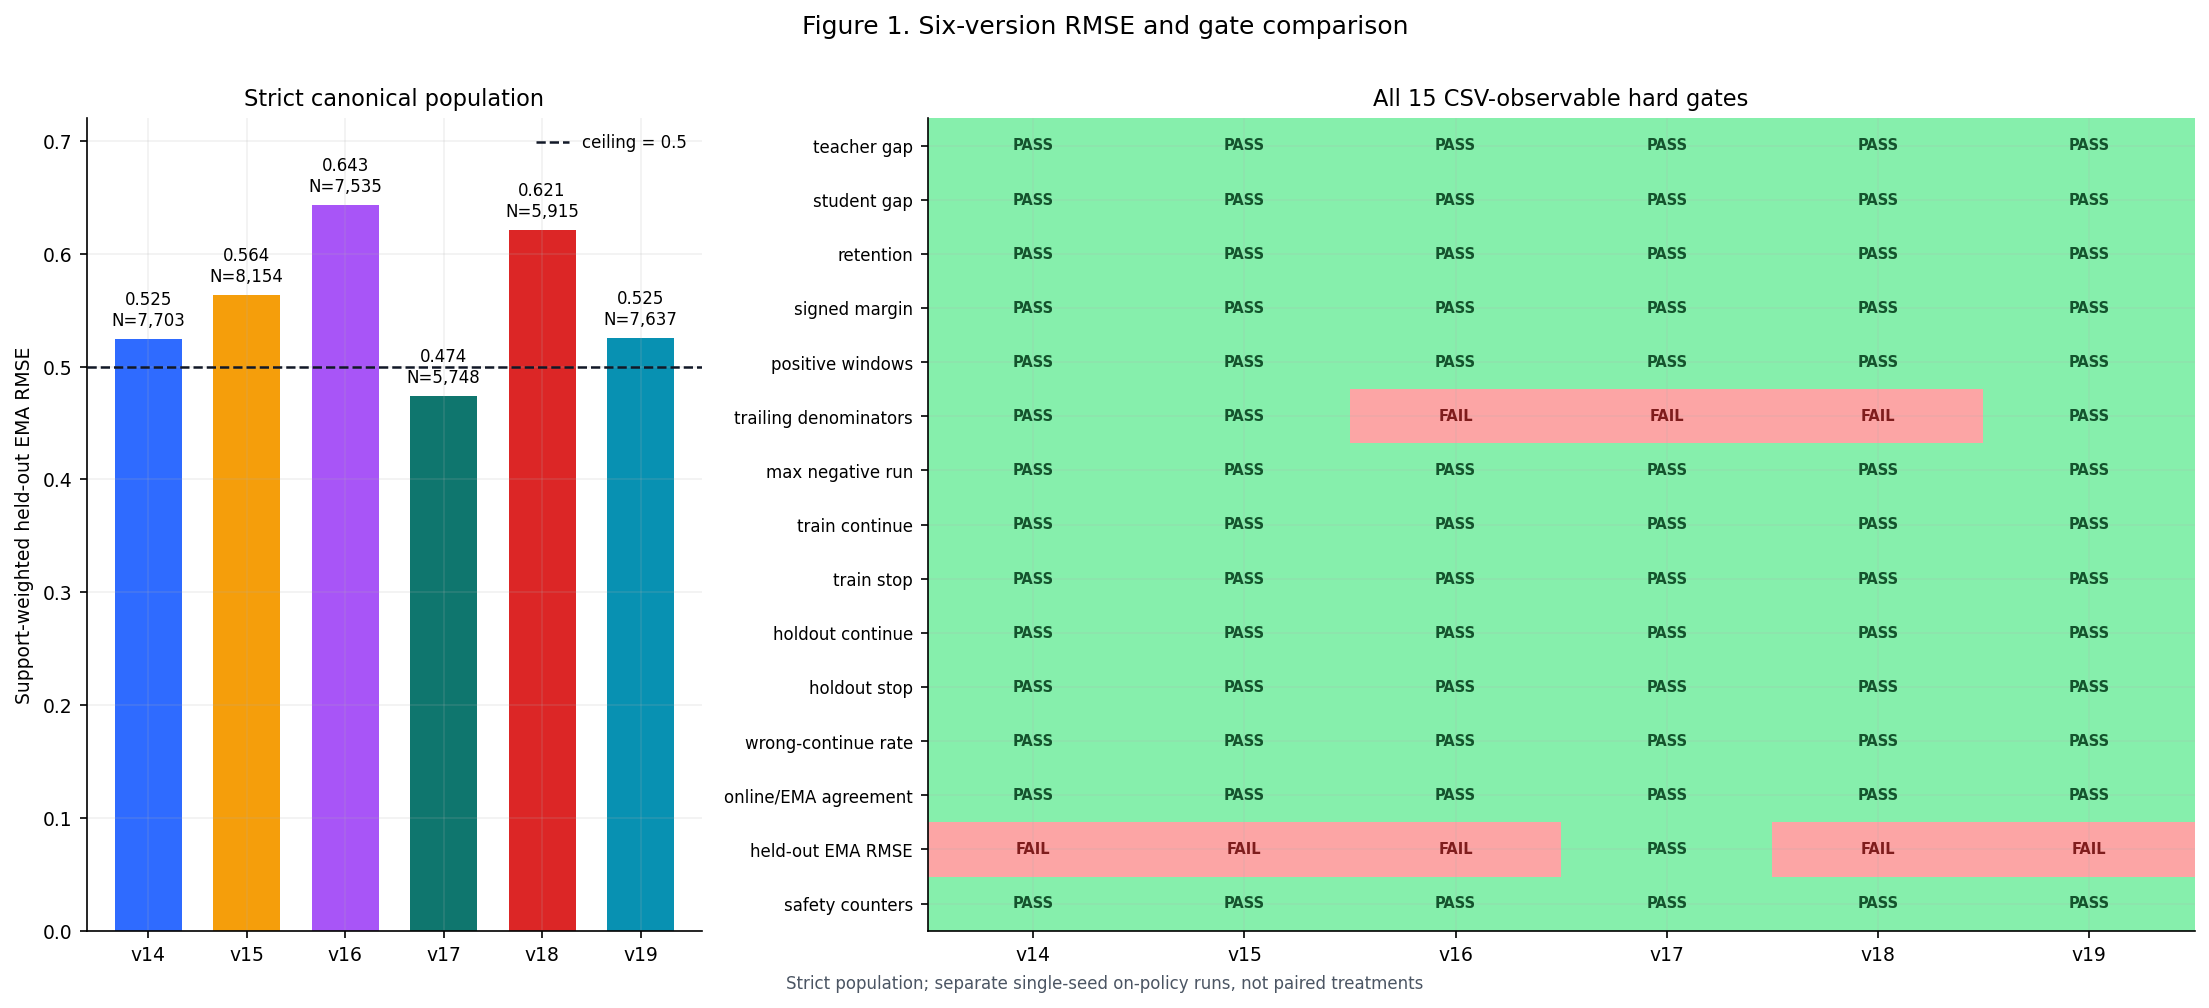

In [4]:
def summarize_calibration(version, frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    support = int(require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum())
    ema_rmse = pooled_rmse(window, 'actor/voc_gate_holdout_td_rmse')
    ema_sse = support * ema_rmse**2
    threshold_sse = support * RMSE_CEILING**2
    return {
        'version': version, 'window': label, 'rows': len(window), 'support': support,
        'ema_bias': pooled_mean(window, 'actor/voc_gate_holdout_td_bias', HOLDOUT_COUNT),
        'ema_mae': pooled_mean(window, 'actor/voc_gate_holdout_td_mae', HOLDOUT_COUNT),
        'ema_rmse': ema_rmse, 'online_rmse': pooled_rmse(window, 'actor/voc_holdout_td_rmse'),
        'ema_sse': ema_sse, 'threshold_sse': threshold_sse, 'excess_sse': ema_sse - threshold_sse,
        'relative_sse_reduction_to_ceiling': max(0.0, (ema_sse - threshold_sse) / ema_sse),
    }

calibration_rows = []
for version, frame in canonical.items():
    calibration_rows.extend(summarize_calibration(version, frame, label, lower, upper) for label, lower, upper in WINDOWS)
    calibration_rows.append(summarize_calibration(version, frame, 'Full', LOWER_STEP, UPPER_STEP))
calibration = pd.DataFrame(calibration_rows)
expected_window_rmse = {
    ('v14', 'W1'): 0.3070468494240733, ('v14', 'W2'): 0.4805763254032396, ('v14', 'W3'): 0.8753410807478021, ('v14', 'Full'): 0.5247954789453232,
    ('v15', 'W1'): 0.6350000482991449, ('v15', 'W2'): 0.5262197892944133, ('v15', 'W3'): 0.5362964249791570, ('v15', 'Full'): 0.5637126651551874,
    ('v16', 'W1'): 0.42412219735332535, ('v16', 'W2'): 0.9513859413944138, ('v16', 'W3'): 0.8161048402729426, ('v16', 'Full'): 0.6433996228747740,
    ('v17','W1'):0.5044903887648509,('v17','W2'):0.3328853383580048,('v17','W3'):0.5455878532763281,('v17','Full'):0.4739621233029751,
    ('v18','W1'):0.5198341483850172,('v18','W2'):0.6682381798094105,('v18','W3'):0.6345936073099058,('v18','Full'):0.6213871746707746,
    ('v19','W1'):0.9494220793526011,('v19','W2'):0.04412178311776224,('v19','W3'):0.5081403257530148,('v19','Full'):0.5251721239021903,
}
for row in calibration.itertuples(index=False):
    assert np.isclose(row.ema_rmse, expected_window_rmse[(row.version, row.window)], rtol=0.0, atol=1e-14)
full_sse = calibration.loc[calibration.window == 'Full'].reset_index(drop=True)
assert np.isclose(full_sse.set_index('version').loc['v16', 'ema_sse'], 3119.2117679806, rtol=0.0, atol=1e-10)
assert np.isclose(full_sse.set_index('version').loc['v19', 'ema_sse'], 2106.32858701171, rtol=0.0, atol=1e-10)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(calibration)
    display(full_sse[['version', 'support', 'ema_rmse', 'ema_sse', 'threshold_sse', 'excess_sse', 'relative_sse_reduction_to_ceiling']])

versions=list(VERSIONS)
fig,axes=plt.subplots(1,2,figsize=(14.8,6.4),gridspec_kw={'width_ratios':[0.85,1.75]})
rmse_values=[authoritative[v]['heldout_ema_rmse'] for v in versions]
bars=axes[0].bar(np.arange(len(versions)),rmse_values,color=[COLORS[v] for v in versions],width=.68)
axes[0].axhline(RMSE_CEILING,color='#111827',linewidth=1.2,linestyle='--',label='ceiling = 0.5')
for bar,version,value in zip(bars,versions,rmse_values):
 support=int(full_sse.set_index('version').loc[version,'support']);axes[0].text(bar.get_x()+bar.get_width()/2,value+.012,f'{value:.3f}\nN={support:,}',ha='center',fontsize=8)
axes[0].set_xticks(np.arange(len(versions)),versions);axes[0].set_ylim(0,.72);axes[0].set_ylabel('Support-weighted held-out EMA RMSE');axes[0].set_title('Strict canonical population');axes[0].legend(frameon=False,fontsize=8)
from matplotlib.colors import ListedColormap
pass_matrix=np.array([[bool(row[f'{v}_pass']) for v in versions] for _,row in gate_table.iterrows()],dtype=int)
axes[1].imshow(pass_matrix,cmap=ListedColormap(['#FCA5A5','#86EFAC']),vmin=0,vmax=1,aspect='auto')
short=['teacher gap','student gap','retention','signed margin','positive windows','trailing denominators','max negative run','train continue','train stop','holdout continue','holdout stop','wrong-continue rate','online/EMA agreement','held-out EMA RMSE','safety counters']
axes[1].set_yticks(np.arange(len(short)),short);axes[1].set_xticks(np.arange(len(versions)),versions)
for i in range(15):
 for j in range(len(versions)): axes[1].text(j,i,'PASS' if pass_matrix[i,j] else 'FAIL',ha='center',va='center',fontsize=7,fontweight='bold',color='#14532D' if pass_matrix[i,j] else '#7F1D1D')
axes[1].set_title('All 15 CSV-observable hard gates');axes[1].tick_params(axis='y',labelsize=8)
fig.suptitle('Figure 1. Six-version RMSE and gate comparison',fontsize=12,y=1.01);fig.text(.5,-.005,'Strict population; separate single-seed on-policy runs, not paired treatments',ha='center',color='#4B5563',fontsize=8);fig.tight_layout();plt.show();rendered_figure_count+=1


### 3. Online/EMA calibration and tau chronology

Train moments are reconstructed by subtracting held-out sufficient statistics from all-example statistics; this does not manufacture event-level data. Figure 2 compares v18 (`tau=0.1`) and v19 (`tau=1.0`) fixed-window online/EMA error and sign support. “Reappearance” means return after an explicitly enumerated observed zero-support run, never first-ever support. V19 online and EMA sufficient statistics match at every logged row, but this removes neither trajectory dependence nor the RMSE gate.


   version q_source    split  support          bias          mae         rmse
0      v14      EMA    train    54013  0.0001757239 0.2257031850 0.5865118456
1      v14      EMA  holdout     7703 -0.0173424071 0.2182068335 0.5247954789
2      v14   Online    train    54013  0.0004707586 0.2268510069 0.5867927997
3      v14   Online  holdout     7703 -0.0168082496 0.2190239446 0.5248123567
4      v15      EMA    train    57906 -0.0034510450 0.1969348060 0.4891362534
5      v15      EMA  holdout     8154  0.0058673889 0.2649639505 0.5637126652
6      v15   Online    train    57906 -0.0030080349 0.1991153192 0.4894692565
7      v15   Online  holdout     8154  0.0061157450 0.2675517220 0.5646944858
8      v16      EMA    train    52672  0.0168319447 0.2661945921 0.5999551131
9      v16      EMA  holdout     7535  0.0120960360 0.3013661225 0.6433996229
10     v16   Online    train    52672  0.0014854931 0.2644941544 0.5997760072
11     v16   Online  holdout     7535 -0.0036510219 0.2999145367

  version      ema_mse   pooled_bias  within_row_variance  between_row_bias_variance  pooled_bias_squared  within_share  between_share  bias_squared_share
0     v14 0.2754102947 -0.0173424071         0.1785494537               0.0965600819         0.0003007591  0.6483034844   0.3506044755        0.0010920401
1     v15 0.3177719689  0.0058673889         0.1892163488               0.1285211938         0.0000344263  0.5954469473   0.4044447163        0.0001083363
2     v16 0.4139630747  0.0120960360         0.2616547655               0.1521619951         0.0001463141  0.6320727174   0.3675738354        0.0003534472
3     v17 0.2246400943  0.0722080491         0.1484540013               0.0709720907         0.0052140024  0.6608526484   0.3159368807        0.0232104708
4     v18 0.3861220208  0.0061021521         0.2520852506               0.1339995340         0.0000372363  0.6528642165   0.3470393470        0.0000964365
5     v19 0.2758057597 -0.0213001803         0.1654222928             

                                                                       online_zero_runs_all_rows                                                                       ema_zero_runs_all_rows online_zero_runs_canonical ema_zero_runs_canonical online_trailing_invalid_endpoints ema_trailing_invalid_endpoints
v18                 [(480, 2544), (6208, 11392), (13472, 19664), (37296, 47920), (61696, 72672)]                                 [(480, 4608), (7264, 22768), (43872, 56080), (64496, 76784)]           [(70624, 72672)]        [(70624, 76784)]                                []          [74704, 75744, 76784]
v19  [(480, 2544), (5104, 9216), (10560, 21936), (50800, 54912), (56976, 56976), (95680, 97760)]  [(480, 2544), (5104, 9216), (10560, 21936), (50800, 54912), (56976, 56976), (95680, 97760)]           [(95680, 97760)]        [(95680, 97760)]                                []                             []

  version  from_step  through_step  rows  positive  negative  tie  depth_bin_0  depth_bin_1  depth_bin_2_3  depth_bin_4_7  depth_bin_8_15  depth_bin_16_plus
0     v18      64496         76784    13         0     15185    0        13296         1672            217              0               0                  0
1     v19      95680         97760     3         0      3519    0         3072          399             48              0               0                  0

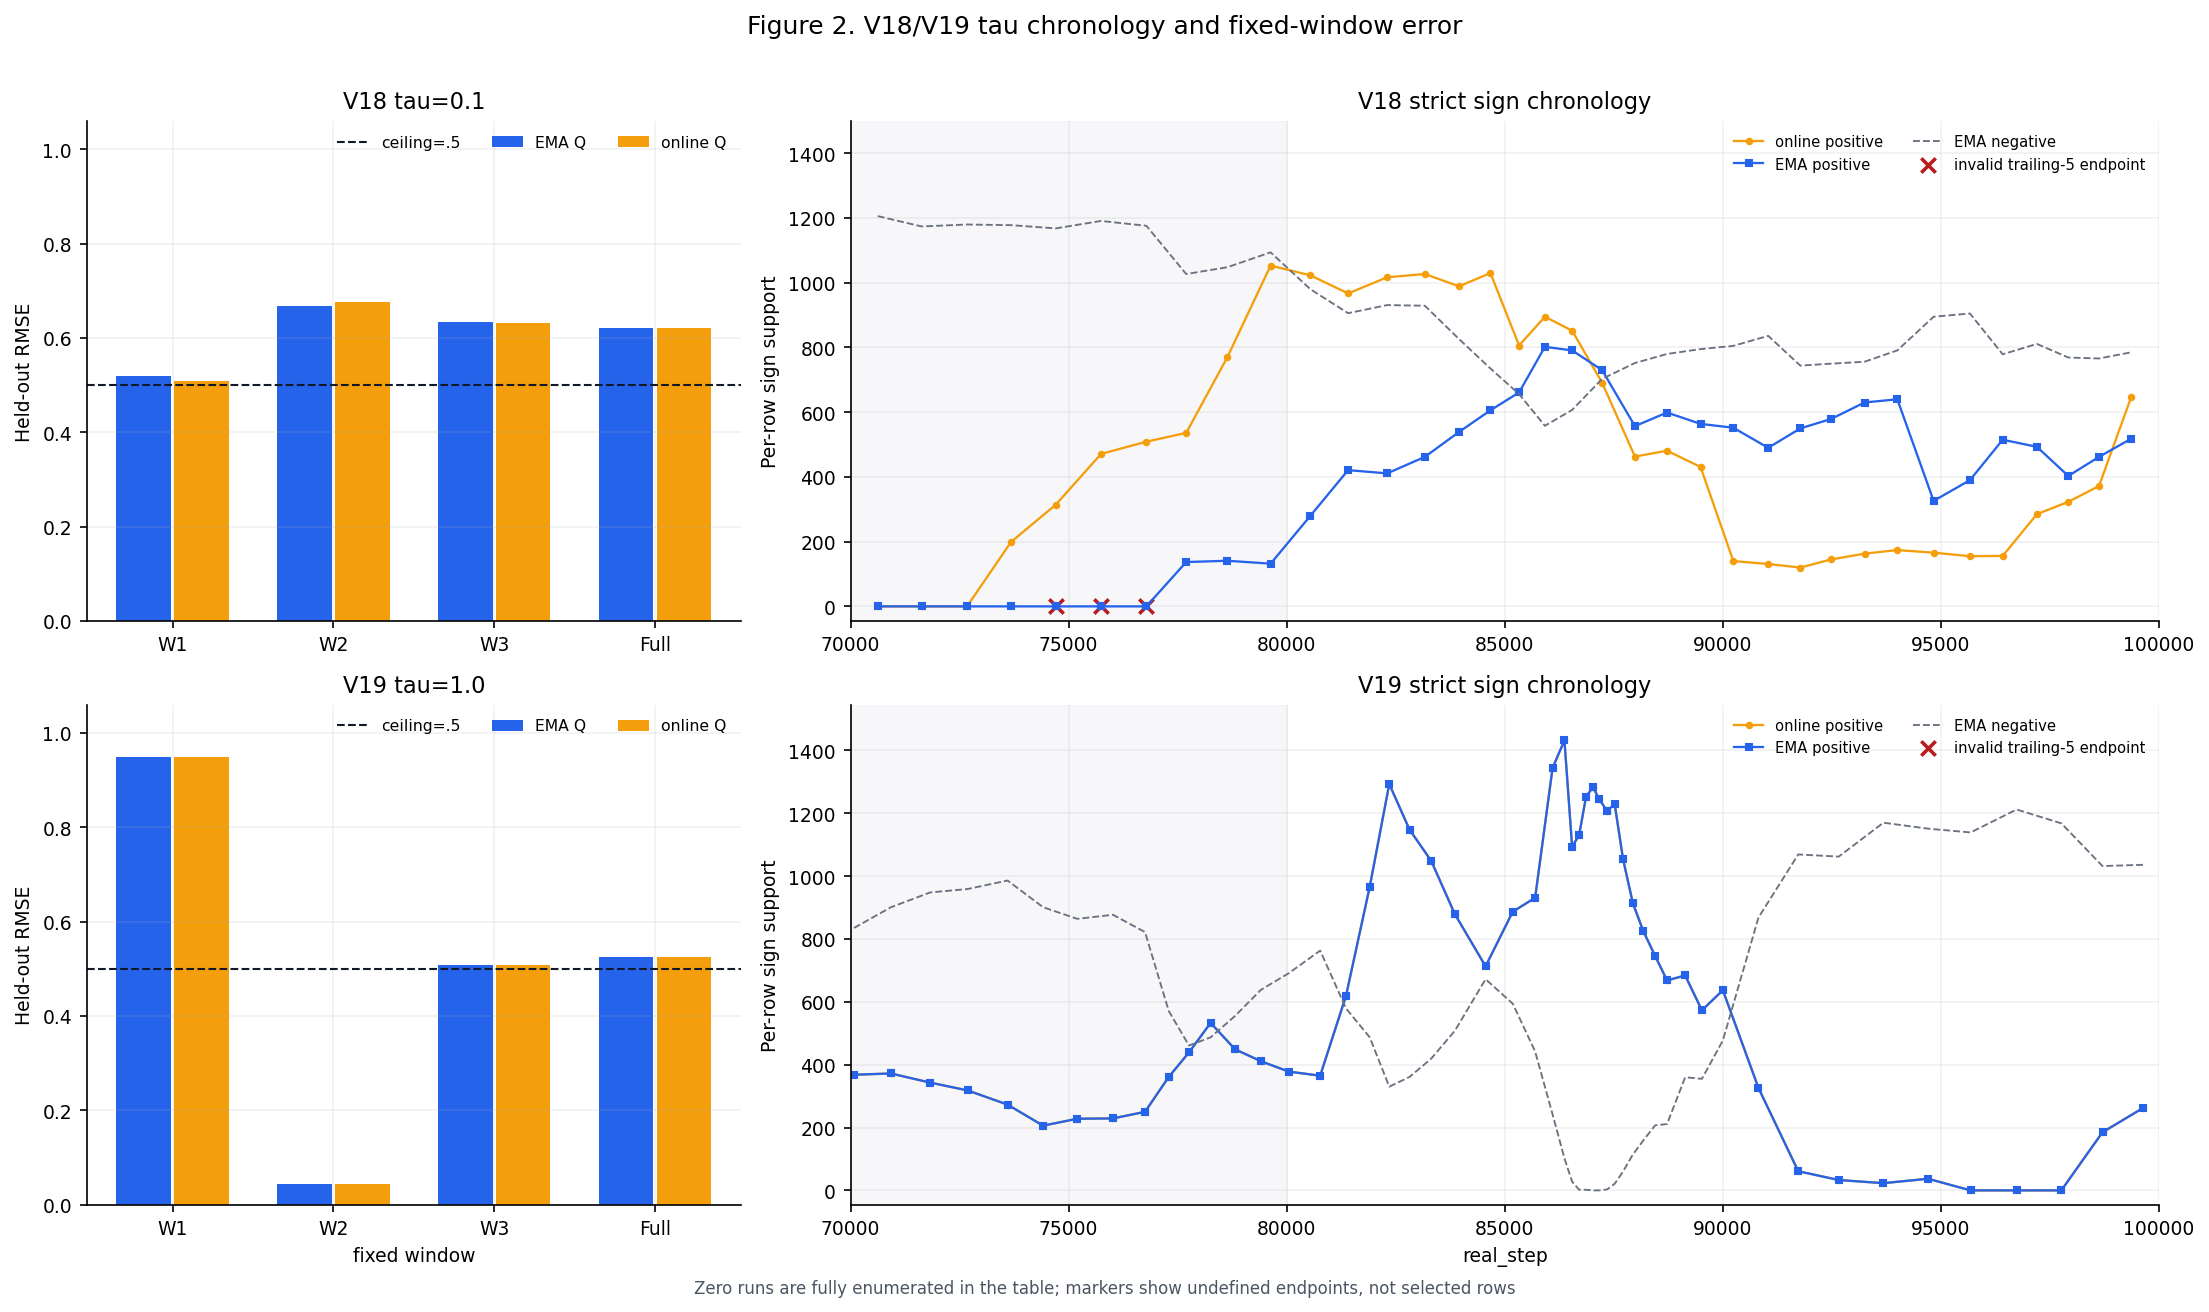

In [5]:
def reconstruct_split_moments(version, frame, source_label, prefix):
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    all_n = train_n + holdout_n
    all_bias = frame[f'{prefix}_td_bias'].to_numpy(dtype=np.float64)
    all_mae = frame[f'{prefix}_td_mae'].to_numpy(dtype=np.float64)
    all_rmse = frame[f'{prefix}_td_rmse'].to_numpy(dtype=np.float64)
    holdout_bias = frame[f'{prefix}_holdout_td_bias'].to_numpy(dtype=np.float64)
    holdout_mae = frame[f'{prefix}_holdout_td_mae'].to_numpy(dtype=np.float64)
    holdout_rmse = frame[f'{prefix}_holdout_td_rmse'].to_numpy(dtype=np.float64)
    train_sum = np.sum(all_n * all_bias - holdout_n * holdout_bias)
    train_abs = np.sum(all_n * all_mae - holdout_n * holdout_mae)
    train_sse = np.sum(all_n * np.square(all_rmse) - holdout_n * np.square(holdout_rmse))
    assert train_abs >= 0 and train_sse >= 0
    return [
        {'version': version, 'q_source': source_label, 'split': 'train', 'support': int(train_n.sum()), 'bias': train_sum / train_n.sum(), 'mae': train_abs / train_n.sum(), 'rmse': np.sqrt(train_sse / train_n.sum())},
        {'version': version, 'q_source': source_label, 'split': 'holdout', 'support': int(holdout_n.sum()), 'bias': np.dot(holdout_n, holdout_bias) / holdout_n.sum(), 'mae': np.dot(holdout_n, holdout_mae) / holdout_n.sum(), 'rmse': np.sqrt(np.dot(holdout_n, np.square(holdout_rmse)) / holdout_n.sum())},
    ]

split_rows = []
for version, frame in canonical.items():
    split_rows.extend(reconstruct_split_moments(version, frame, 'EMA', 'actor/voc_gate'))
    split_rows.extend(reconstruct_split_moments(version, frame, 'Online', 'actor/voc'))
split_moments = pd.DataFrame(split_rows)
expected_split_rmse = {
    ('v14', 'EMA', 'train'): 0.5865118456123475, ('v14', 'EMA', 'holdout'): 0.5247954789453232,
    ('v14', 'Online', 'train'): 0.5867927997052582, ('v14', 'Online', 'holdout'): 0.5248123566562356,
    ('v15', 'EMA', 'train'): 0.48913625344503686, ('v15', 'EMA', 'holdout'): 0.5637126651551874,
    ('v15', 'Online', 'train'): 0.48946925650925704, ('v15', 'Online', 'holdout'): 0.5646944857965209,
    ('v16', 'EMA', 'train'): 0.5999551130525911, ('v16', 'EMA', 'holdout'): 0.6433996228747740,
    ('v16', 'Online', 'train'): 0.5997760072212164, ('v16', 'Online', 'holdout'): 0.6432134673573406,
    ('v17', 'EMA', 'train'): 0.6696040559045617, ('v17', 'EMA', 'holdout'): 0.4739621233029751,
    ('v17','Online','train'):0.6689091558309008,('v17','Online','holdout'):0.4695661556492494,
    ('v18','EMA','train'):0.7395385218782626,('v18','EMA','holdout'):0.6213871746707746,
    ('v18','Online','train'):0.7367944445983604,('v18','Online','holdout'):0.6212603749561236,
    ('v19','EMA','train'):0.567940642948387,('v19','EMA','holdout'):0.5251721239021903,
    ('v19','Online','train'):0.567940642948387,('v19','Online','holdout'):0.5251721239021903,
}
for row in split_moments.itertuples(index=False):
    assert np.isclose(row.rmse, expected_split_rmse[(row.version, row.q_source, row.split)], rtol=0.0, atol=1e-14), (row.version, row.q_source, row.split)

decomposition_rows = []
for version, frame in canonical.items():
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_bias = frame['actor/voc_gate_holdout_td_bias'].to_numpy(dtype=np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    total_n = holdout_n.sum()
    pooled_bias = np.dot(holdout_n, row_bias) / total_n
    total_mse = np.dot(holdout_n, np.square(row_rmse)) / total_n
    within_row_variance = np.dot(holdout_n, np.square(row_rmse) - np.square(row_bias)) / total_n
    between_row_bias_variance = np.dot(holdout_n, np.square(row_bias - pooled_bias)) / total_n
    pooled_bias_squared = pooled_bias**2
    assert np.isclose(total_mse, within_row_variance + between_row_bias_variance + pooled_bias_squared, rtol=0.0, atol=1e-14)
    decomposition_rows.append({
        'version': version, 'ema_mse': total_mse, 'pooled_bias': pooled_bias,
        'within_row_variance': within_row_variance, 'between_row_bias_variance': between_row_bias_variance,
        'pooled_bias_squared': pooled_bias_squared, 'within_share': within_row_variance / total_mse,
        'between_share': between_row_bias_variance / total_mse, 'bias_squared_share': pooled_bias_squared / total_mse,
    })
error_structure = pd.DataFrame(decomposition_rows)
assert np.isclose(error_structure.set_index('version').loc['v16', 'ema_mse'], 0.4139630747154015, rtol=0.0, atol=1e-14)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(split_moments)
    display(error_structure)

def zero_positive_runs(frame, column):
    positive=require_counts(frame[column],column)
    indices=np.flatnonzero(positive==0)
    runs=[]
    if len(indices):
        start=previous=int(indices[0])
        for index in indices[1:]:
            index=int(index)
            if index!=previous+1:
                runs.append((int(frame.real_step.iloc[start]),int(frame.real_step.iloc[previous])))
                start=index
            previous=index
        runs.append((int(frame.real_step.iloc[start]),int(frame.real_step.iloc[previous])))
    return runs

chronology={}
online_trailing_invalid={}
for version in ('v18','v19'):
    full=frames[version];pop=canonical[version]
    online_col='actor/voc_acceptance_delta_q_positive_count';ema_col=f'{GATE_PREFIX}_delta_q_positive_count'
    op=require_counts(pop[online_col],version+' online positive')
    on=require_counts(pop['actor/voc_acceptance_delta_q_negative_count'],version+' online negative')
    ep=require_counts(pop[ema_col],version+' EMA positive')
    en=require_counts(pop[f'{GATE_PREFIX}_delta_q_negative_count'],version+' EMA negative')
    invalid=[]
    for endpoint in range(4,len(pop)):
        if int(op[endpoint-4:endpoint+1].sum())==0 or int(on[endpoint-4:endpoint+1].sum())==0:
            invalid.append(int(pop.real_step.iloc[endpoint]))
    online_trailing_invalid[version]=invalid
    chronology[version]={
        'online_zero_runs_all_rows':zero_positive_runs(full,online_col),
        'ema_zero_runs_all_rows':zero_positive_runs(full,ema_col),
        'online_zero_runs_canonical':zero_positive_runs(pop,online_col),
        'ema_zero_runs_canonical':zero_positive_runs(pop,ema_col),
        'online_trailing_invalid_endpoints':invalid,
        'ema_trailing_invalid_endpoints':trailing_results[version].loc[trailing_results[version].student_gap.isna(),'real_step'].astype(int).tolist(),
    }
assert chronology['v18']['online_zero_runs_all_rows'][-1]==(61696,72672)
assert chronology['v18']['ema_zero_runs_all_rows'][-1]==(64496,76784)
assert chronology['v18']['online_trailing_invalid_endpoints']==[]
assert chronology['v18']['ema_trailing_invalid_endpoints']==[74704,75744,76784]
assert chronology['v19']['online_zero_runs_all_rows']==chronology['v19']['ema_zero_runs_all_rows']
assert chronology['v19']['online_zero_runs_canonical']==[(95680,97760)]
assert chronology['v19']['online_trailing_invalid_endpoints']==[] and chronology['v19']['ema_trailing_invalid_endpoints']==[]
v19_negative_zero_steps=canonical['v19'].loc[canonical['v19'][f'{GATE_PREFIX}_delta_q_negative_count']==0,'real_step'].astype(int).tolist()
assert v19_negative_zero_steps==[87024,87168]
assert (int(trailing_results['v19'].positive_n.min()),int(trailing_results['v19'].negative_n.min()))==(60,7)
for suffix in ('td_bias','td_mae','td_rmse'):
    assert np.array_equal(frames['v19'][f'actor/voc_{suffix}'].to_numpy(),frames['v19'][f'actor/voc_gate_{suffix}'].to_numpy())
    assert np.array_equal(frames['v19'][f'actor/voc_holdout_{suffix}'].to_numpy(),frames['v19'][f'actor/voc_gate_holdout_{suffix}'].to_numpy())
for suffix in ('positive_count','negative_count','tie_count','nontie_count'):
    assert np.array_equal(frames['v19'][f'actor/voc_acceptance_delta_q_{suffix}'].to_numpy(),frames['v19'][f'actor/voc_gate_acceptance_delta_q_{suffix}'].to_numpy())

extinction_rows=[]
for version,(lower,upper) in {'v18':(64496,76784),'v19':(95680,97760)}.items():
    full=frames[version];extinct=full.loc[(full.real_step>=lower)&(full.real_step<=upper)]
    row={'version':version,'from_step':lower,'through_step':upper,'rows':len(extinct),'positive':int(extinct[f'{GATE_PREFIX}_delta_q_positive_count'].sum()),'negative':int(extinct[f'{GATE_PREFIX}_delta_q_negative_count'].sum()),'tie':int(extinct[f'{GATE_PREFIX}_delta_q_tie_count'].sum())}
    for suffix in ('depth_bin_0','depth_bin_1','depth_bin_2_3','depth_bin_4_7','depth_bin_8_15','depth_bin_16_plus'):
        row[suffix]=int(extinct[f'actor/voc_gate_{suffix}_count'].sum())
    extinction_rows.append(row)
extinction_composition=pd.DataFrame(extinction_rows)
assert extinction_composition.set_index('version').loc['v18',['positive','negative','tie','depth_bin_0','depth_bin_1','depth_bin_2_3']].astype(int).tolist()==[0,15185,0,13296,1672,217]
assert extinction_composition.set_index('version').loc['v19',['positive','tie']].astype(int).tolist()==[0,0]
display(pd.DataFrame(chronology).T)
display(extinction_composition)

fig,axes=plt.subplots(2,2,figsize=(14.8,8.4),gridspec_kw={'width_ratios':[.86,1.72]})
for ri,version in enumerate(('v18','v19')):
    windows=calibration.loc[calibration.version==version].set_index('window').loc[['W1','W2','W3','Full']];x=np.arange(4)
    axes[ri,0].bar(x-.18,windows.ema_rmse,width=.34,color='#2563EB',label='EMA Q')
    axes[ri,0].bar(x+.18,windows.online_rmse,width=.34,color='#F59E0B',label='online Q')
    axes[ri,0].axhline(.5,color='#111827',linestyle='--',linewidth=1,label='ceiling=.5')
    axes[ri,0].set_xticks(x,['W1','W2','W3','Full']);axes[ri,0].set_ylim(0,1.06);axes[ri,0].set_ylabel('Held-out RMSE')
    axes[ri,0].set_title(version.upper()+(' tau=0.1' if version=='v18' else ' tau=1.0'))
    axes[ri,0].legend(frameon=False,fontsize=7.5,ncol=3)
    pop=canonical[version];steps=pop.real_step.to_numpy(dtype=int)
    op=require_counts(pop['actor/voc_acceptance_delta_q_positive_count'],version+' op chart')
    ep=require_counts(pop[f'{GATE_PREFIX}_delta_q_positive_count'],version+' ep chart')
    en=require_counts(pop[f'{GATE_PREFIX}_delta_q_negative_count'],version+' en chart')
    invalid=trailing_results[version].loc[trailing_results[version].student_gap.isna(),'real_step'].to_numpy(dtype=int)
    axes[ri,1].plot(steps,op,color='#F59E0B',marker='o',markersize=2.6,linewidth=1.1,label='online positive')
    axes[ri,1].plot(steps,ep,color='#2563EB',marker='s',markersize=2.5,linewidth=1.1,label='EMA positive')
    axes[ri,1].plot(steps,en,color='#6B7280',linestyle='--',linewidth=.9,label='EMA negative')
    axes[ri,1].scatter(invalid,np.zeros_like(invalid),marker='x',s=48,color='#B91C1C',linewidth=1.7,label='invalid trailing-5 endpoint')
    axes[ri,1].axvspan(70000,80000,color='#F3F4F6',alpha=.65,zorder=-1)
    axes[ri,1].set_xlim(70000,100000);axes[ri,1].set_ylim(-45,max(1500,int(max(op.max(),ep.max(),en.max())*1.08)))
    axes[ri,1].set_ylabel('Per-row sign support');axes[ri,1].set_title(version.upper()+' strict sign chronology')
    axes[ri,1].legend(frameon=False,fontsize=7.1,ncol=2,loc='upper right')
axes[1,0].set_xlabel('fixed window');axes[1,1].set_xlabel('real_step')
fig.suptitle('Figure 2. V18/V19 tau chronology and fixed-window error',fontsize=12,y=1.01)
fig.text(.5,-.005,'Zero runs are fully enumerated in the table; markers show undefined endpoints, not selected rows',ha='center',color='#4B5563',fontsize=8)
fig.tight_layout();plt.show();rendered_figure_count+=1


### 4. Frozen checkpoint coordinates, cadence, clipping, tail, and composition evidence

All six terminal actor checkpoints are hash-verified before read-only deserialization. Raw online/EMA rows are always interpreted as `[CONTINUE, STOP]`; schemas 11–12 store Q-Adam moment rows semantically as `[common, difference]`, while schemas 6–10 store raw-row moments whose common/difference norms are derived. V18 and v19 step-480 raw online parameters and Adam state are bitwise equal, while their EMA/projection tensors differ exactly at the tau boundary. Figure 3 combines optimizer state, cadence/clipping, SSE concentration, and support composition. Cross-run state magnitudes remain descriptive, not treatment-comparable.


In [6]:
# Hash-bound, read-only checkpoint coordinate diagnostics; no training or mutation.
import contextlib
import io
import math
import torch

STEP_CHECKPOINTS = {
 'v16_step480': (VERSIONS['v16']['snapshot']/'runs'/VERSIONS['v16']['xpid']/'ckp_actor.tar_step_480','3a9f8f9199726902bf789afe7910f61c89f437cb4099476bcb709ecf6a06873c'),
 'v17_step480': (VERSIONS['v17']['snapshot']/'runs'/VERSIONS['v17']['xpid']/'ckp_actor.tar_step_480','d93d16150136f67e8a9d200aefb31b7c2ecbb8a58ed01af4e092c02ce4669b66'),
 'v17_terminal': (VERSIONS['v17']['snapshot']/'runs'/VERSIONS['v17']['xpid']/'ckp_actor.tar_step_100000','7d7eadebd7b333181efda0f40be310d85a4286fce4376b43304873b15456269c'),
 'v18_step480': (VERSIONS['v18']['snapshot']/'runs'/VERSIONS['v18']['xpid']/'ckp_actor.tar_step_480','7890c152c388d77d730fde5afb3b610db5b927153f91d41ce57acf4d43bf67e7'),
 'v18_terminal': (VERSIONS['v18']['snapshot']/'runs'/VERSIONS['v18']['xpid']/'ckp_actor.tar_step_100064','1bb2f11271c2b511ca4fdc95d12a74848fe2ffafbfe02508fd85b7410690ad9a'),
 'v19_step480': (VERSIONS['v19']['snapshot']/'runs'/VERSIONS['v19']['xpid']/'ckp_actor.tar_step_480','3e03e4e3bca90e38ad5eb717dbb183d0ef7169ada8d025a1bd5f030cde999500'),
 'v19_terminal': (VERSIONS['v19']['snapshot']/'runs'/VERSIONS['v19']['xpid']/'ckp_actor.tar_step_100576','6597abf7b16b75888fab951760c11ee36a3996782761a742c6f9e11cd57f3785'),
}
for path,expected_hash in STEP_CHECKPOINTS.values(): assert path.is_file() and sha256_file(path)==expected_hash

def load_frozen_checkpoint(path):
    with contextlib.redirect_stdout(io.StringIO()),contextlib.redirect_stderr(io.StringIO()):
        return torch.load(path,map_location='cpu',weights_only=False)
terminal_checkpoints={version:load_frozen_checkpoint(spec['actor_checkpoint']) for version,spec in VERSIONS.items()}
step_checkpoints={label:load_frozen_checkpoint(path) for label,(path,_) in STEP_CHECKPOINTS.items()}
SQRT2=math.sqrt(2.0)
def orthonormal_norms(rows):
    rows=rows.detach().double();assert rows.shape[0]==2
    return float(torch.linalg.vector_norm((rows[0]+rows[1])/SQRT2)),float(torch.linalg.vector_norm((rows[0]-rows[1])/SQRT2))
def projection_matches(x):
    ew=x['voc_ema_gate_head_state_dict']['weight'];eb=x['voc_ema_gate_head_state_dict']['bias'];gw=x['actor_net_state_dict']['voc_gate_head.weight'];gb=x['actor_net_state_dict']['voc_gate_head.bias']
    return bool(torch.equal(gw,20*(ew[0]-ew[1]).reshape(1,-1)) and torch.equal(gb,20*(eb[0]-eb[1]).reshape(1)))

checkpoint_rows=[]
for version,x in terminal_checkpoints.items():
    online=x['actor_net_state_dict']['voc_head.weight'];ema=x['voc_ema_gate_head_state_dict']['weight'];state=x['voc_optimizer_state_dict']['state'][0]
    stored_moment=state['exp_avg']
    if version in ('v18','v19'):
        moment_norms=tuple(float(torch.linalg.vector_norm(row.double())) for row in stored_moment);moment_semantics='stored m/d'
    else:
        moment_norms=orthonormal_norms(stored_moment);moment_semantics='raw C/S; derived m/d'
    checkpoint_rows.append({
        'version':version,'optimizer_step':float(state['step']),'ema_update_count':int(x['voc_ema_gate_update_count']),
        'raw_online_common_norm':orthonormal_norms(online)[0],'raw_online_difference_norm':orthonormal_norms(online)[1],
        'raw_ema_common_norm':orthonormal_norms(ema)[0],'raw_ema_difference_norm':orthonormal_norms(ema)[1],
        'online_ema_weight_l2':float(torch.linalg.vector_norm((online-ema).double())),
        'moment_row0_or_m_norm':moment_norms[0],'moment_row1_or_d_norm':moment_norms[1],
        'moment_semantics':moment_semantics,'projection_exact':projection_matches(x),
    })
checkpoint_state=pd.DataFrame(checkpoint_rows)
assert checkpoint_state.projection_exact.all()

v18_initial=step_checkpoints['v18_step480'];v19_initial=step_checkpoints['v19_step480'];v19_terminal=step_checkpoints['v19_terminal']
for container,key in (('actor_net_state_dict','voc_head.weight'),('actor_net_state_dict','voc_head.bias')):
    assert torch.equal(v18_initial[container][key],v19_initial[container][key])
for pid in (0,1):
    for field in ('step','exp_avg','exp_avg_sq'):
        assert torch.equal(v18_initial['voc_optimizer_state_dict']['state'][pid][field],v19_initial['voc_optimizer_state_dict']['state'][pid][field])
assert not torch.equal(v18_initial['voc_ema_gate_head_state_dict']['weight'],v19_initial['voc_ema_gate_head_state_dict']['weight'])
assert not torch.equal(v18_initial['actor_net_state_dict']['voc_gate_head.weight'],v19_initial['actor_net_state_dict']['voc_gate_head.weight'])
assert torch.equal(v19_terminal['voc_ema_gate_head_state_dict']['weight'],v19_terminal['actor_net_state_dict']['voc_head.weight'])
assert torch.equal(v19_terminal['voc_ema_gate_head_state_dict']['bias'],v19_terminal['actor_net_state_dict']['voc_head.bias'])
assert projection_matches(v19_terminal)
v19_state=v19_terminal['voc_optimizer_state_dict']['state'][0]
v19_md_first=tuple(float(torch.linalg.vector_norm(row.double())) for row in v19_state['exp_avg'])
assert np.allclose(v19_md_first,(94.9880353244062,20.250440032609465),rtol=0,atol=1e-11)
v19_weight_v_mean=tuple(float(row.double().mean()) for row in v19_state['exp_avg_sq'])
v19_group=v19_terminal['voc_optimizer_state_dict']['param_groups'][0]
v19_t=float(v19_state['step']);v19_b1,v19_b2=map(float,v19_group['betas'])
v19_weight_normalized=tuple(float(torch.linalg.vector_norm(row)) for row in ((v19_state['exp_avg'].double()/(1-v19_b1**v19_t))/(torch.sqrt(v19_state['exp_avg_sq'].double()/(1-v19_b2**v19_t))+float(v19_group['eps']))))
v19_bias_state=v19_terminal['voc_optimizer_state_dict']['state'][1]
v19_bias_first=tuple(float(torch.linalg.vector_norm(row.double())) for row in v19_bias_state['exp_avg'])
v19_bias_v_mean=tuple(float(row.double().mean()) for row in v19_bias_state['exp_avg_sq'])
v19_bias_normalized=tuple(float(torch.linalg.vector_norm(row)) for row in ((v19_bias_state['exp_avg'].double()/(1-v19_b1**v19_t))/(torch.sqrt(v19_bias_state['exp_avg_sq'].double()/(1-v19_b2**v19_t))+float(v19_group['eps']))))
v19_raw_bias_norms=orthonormal_norms(v19_terminal['actor_net_state_dict']['voc_head.bias'])
v18_step480_gate_norms=(float(torch.linalg.vector_norm(v18_initial['actor_net_state_dict']['voc_gate_head.weight'].double())),float(torch.linalg.vector_norm(v18_initial['actor_net_state_dict']['voc_gate_head.bias'].double())))
v19_step480_gate_norms=(float(torch.linalg.vector_norm(v19_initial['actor_net_state_dict']['voc_gate_head.weight'].double())),float(torch.linalg.vector_norm(v19_initial['actor_net_state_dict']['voc_gate_head.bias'].double())))
assert np.allclose(v19_weight_v_mean,(81.09018625661385,6.36058033074088),rtol=0,atol=1e-12)
assert np.allclose(v19_weight_normalized,(7.056230298260653,4.931217282004932),rtol=0,atol=1e-12)
assert np.allclose(v19_bias_first,(11.869540214538574,1.1603106260299683),rtol=0,atol=1e-12)
assert np.allclose(v19_bias_v_mean,(834.826416015625,79.38298797607422),rtol=0,atol=1e-12)
assert np.allclose(v19_bias_normalized,(0.16928143826413772,0.05366412888286814),rtol=0,atol=1e-12)
assert np.allclose(v19_raw_bias_norms,(0.0001821920052176032,0.00024041839606817912),rtol=0,atol=1e-15)
assert np.allclose(v18_step480_gate_norms,(0.019151544899105217,0.0008485280559398234),rtol=0,atol=1e-15)
assert np.allclose(v19_step480_gate_norms,(0.19151544598757061,0.0084852809086442),rtol=0,atol=1e-15)
coordinate_diagnostic={
 'v18_v19_step480_raw_online_and_adam_bitwise_equal':True,
 'v18_v19_step480_ema_and_projection_differ':True,
 'v19_terminal_raw_online_equals_raw_ema_torch_equal':True,
 'v19_terminal_stored_md_adam_first_moment_norm':v19_md_first,
 'v19_terminal_stored_md_adam_second_moment_mean':v19_weight_v_mean,
 'v19_terminal_bias_corrected_normalized_md_update_norm':v19_weight_normalized,
 'v19_terminal_stored_md_bias_first_moment_norm':v19_bias_first,
 'v19_terminal_stored_md_bias_second_moment_mean':v19_bias_v_mean,
 'v19_terminal_bias_corrected_normalized_md_bias_update_norm':v19_bias_normalized,
 'v19_terminal_raw_online_bias_common_difference_norm':v19_raw_bias_norms,
 'v18_step480_projected_gate_weight_bias_norm':v18_step480_gate_norms,
 'v19_step480_projected_gate_weight_bias_norm':v19_step480_gate_norms,
 'v19_terminal_projection_matches_raw_ema_difference_bitwise':True,
}
display(checkpoint_state)
display(pd.DataFrame([coordinate_diagnostic]).T.rename(columns={0:'value'}))


  version  optimizer_step  ema_update_count  raw_online_common_norm  raw_online_difference_norm  raw_ema_common_norm  raw_ema_difference_norm  online_ema_weight_l2  moment_row0_or_m_norm  moment_row1_or_d_norm      moment_semantics  projection_exact
0     v14           204.0               204            1.190206e-08                    0.106849         1.186167e-08                 0.104194              0.011449               0.000010              34.812379  raw C/S; derived m/d              True
1     v15           149.0               149            1.241641e-08                    0.079036         1.243055e-08                 0.072953              0.019088               0.000002              36.936165  raw C/S; derived m/d              True
2     v16           250.0               250            1.480921e-01                    0.065869         1.397429e-01                 0.065666              0.015733             102.282270              35.385713  raw C/S; derived m/d              True


                                                                                                      value
v18_v19_step480_raw_online_and_adam_bitwise_equal                                                      True
v18_v19_step480_ema_and_projection_differ                                                              True
v19_terminal_raw_online_equals_raw_ema_torch_equal                                                     True
v19_terminal_stored_md_adam_first_moment_norm                        (94.9880353244062, 20.250440032609465)
v19_terminal_stored_md_adam_second_moment_mean                        (81.09018625661385, 6.36058033074088)
v19_terminal_bias_corrected_normalized_md_update_norm                (7.056230298260653, 4.931217282004932)
v19_terminal_stored_md_bias_first_moment_norm                      (11.869540214538574, 1.1603106260299683)
v19_terminal_stored_md_bias_second_moment_mean                        (834.826416015625, 79.38298797607422)
v19_terminal_bias_corrected_

   version  top_rows             sse  share_of_total_sse
0      v14         1  311.1193808693        0.1466516650
1      v14         5 1157.0343518924        0.5453887626
2      v14        10 1696.9867775455        0.7999049616
3      v15         1  342.7880044517        0.1322937490
4      v15         5 1287.2144514304        0.4967805855
5      v15        10 1798.0507853628        0.6939299982
6      v16         1  492.2218407676        0.1578032777
7      v16         5 1615.3239165497        0.5178628566
8      v16        10 2310.8044459714        0.7408296127
9      v17         1  309.8489329062        0.2399639336
10     v17         5  839.3708974652        0.6500546587
11     v17        10 1081.1482053372        0.8373002087
12     v18         1  436.5794693761        0.1911542636
13     v18         5 1302.1945263183        0.5701597378
14     v18        10 1770.4628772289        0.7751888288
15     v19         1  624.6126647671        0.2965409427
16     v19         5 1614.39268

  version logged_loss_definition  logged_loss  reconstructed_train_half_mse  mse_minus_2huber  tail_energy_fraction
0     v14           Huber beta=1 0.1242177419                  0.1721628949      0.0958903061          0.2784871448
1     v15               half-MSE 0.1197900774                  0.1197900765               NaN                   NaN
2     v16               half-MSE 0.1798656289                  0.1798656294               NaN                   NaN
3     v17           Huber beta=1 0.1706039929                  0.2237197294      0.1062314729          0.2374208864
4     v18           Huber beta=1 0.2055848799                  0.2714330268      0.1316962938          0.2425944540
5     v19           Huber beta=1 0.1213803354                  0.1612782870      0.0797959030          0.2473857595

  version  train_continue  train_stop  train_stop_fraction  holdout_continue  holdout_stop  holdout_stop_fraction  accept_positive  accept_negative  accept_positive_fraction  W1_support_share  W2_support_share  W3_support_share  W3_accept_positive  W3_accept_negative
0     v14           28219       25794         0.4775517005              4016          3687           0.4786446839            32458            29257              0.5259337276      0.4734519019      0.3226015838      0.2039465143                1023               11408
1     v15           31359       26547         0.4584499016              4365          3789           0.4646799117            36718            29339              0.5558532782      0.3007113073      0.4303409370      0.2689477557                6916               10701
2     v16           26897       25775         0.4893491798              3858          3677           0.4879893829            30798            29408              0.5115437000      0.6132714001     

  version  nominal_clip_boundary  all_csv_rows  all_csv_boundary_exceedances  canonical_rows  canonical_boundary_exceedances
0     v14        1608.0000000000           204                             0              63                               0
1     v15        1608.0000000000           149                             1              58                               0
2     v16        1608.0000000000           250                            35              52                               7
3     v17        1608.0000000000           143                            14              36                               5
4     v18        1608.0000000000           156                            13              36                               8
5     v19        1608.0000000000           186                            15              52                               2

  version  all_csv_rows  canonical_rows  median_real_step_gap  mean_real_step_gap  train_support  train_support_per_update
0     v14           204              63        480.0000000000      473.2903225806          54013            857.3492063492
1     v15           149              58        544.0000000000      520.7017543860          57906            998.3793103448
2     v16           250              52        496.0000000000      576.0000000000          52672           1012.9230769231
3     v17           143              36        800.0000000000      845.2571428571          40118           1114.3888888889
4     v18           156              36        784.0000000000      821.0285714286          40458           1123.8333333333
5     v19           186              52        544.0000000000      579.4509803922          54519           1048.4423076923

   version window  updates  train_support  train_support_per_update  logged_q_loss  reconstructed_train_half_mse  q_raw_norm_mean  q_raw_norm_median  q_raw_norm_p95  q_raw_norm_max
0      v14     W1       32          26203            818.8437500000   0.0302336039                  0.0320744263    43.7297306061      35.3293666840   90.1979179382  129.2094879150
1      v14     W2       19          16949            892.0526315789   0.0725517989                  0.0957707799   106.7384317298     110.8502883911  209.8414901733  289.9289245605
2      v14     W3       12          10861            905.0833333333   0.4315883740                  0.6293499035   391.3856321971     313.6181488037  864.6222351074  886.3068847656
3      v14   Full       63          54013            857.3492063492   0.1242177419                  0.1721628949   128.9525264861      62.3866691589  443.1804840088  886.3068847656
4      v15     W1       19          17739            933.6315789474   0.1709406693             

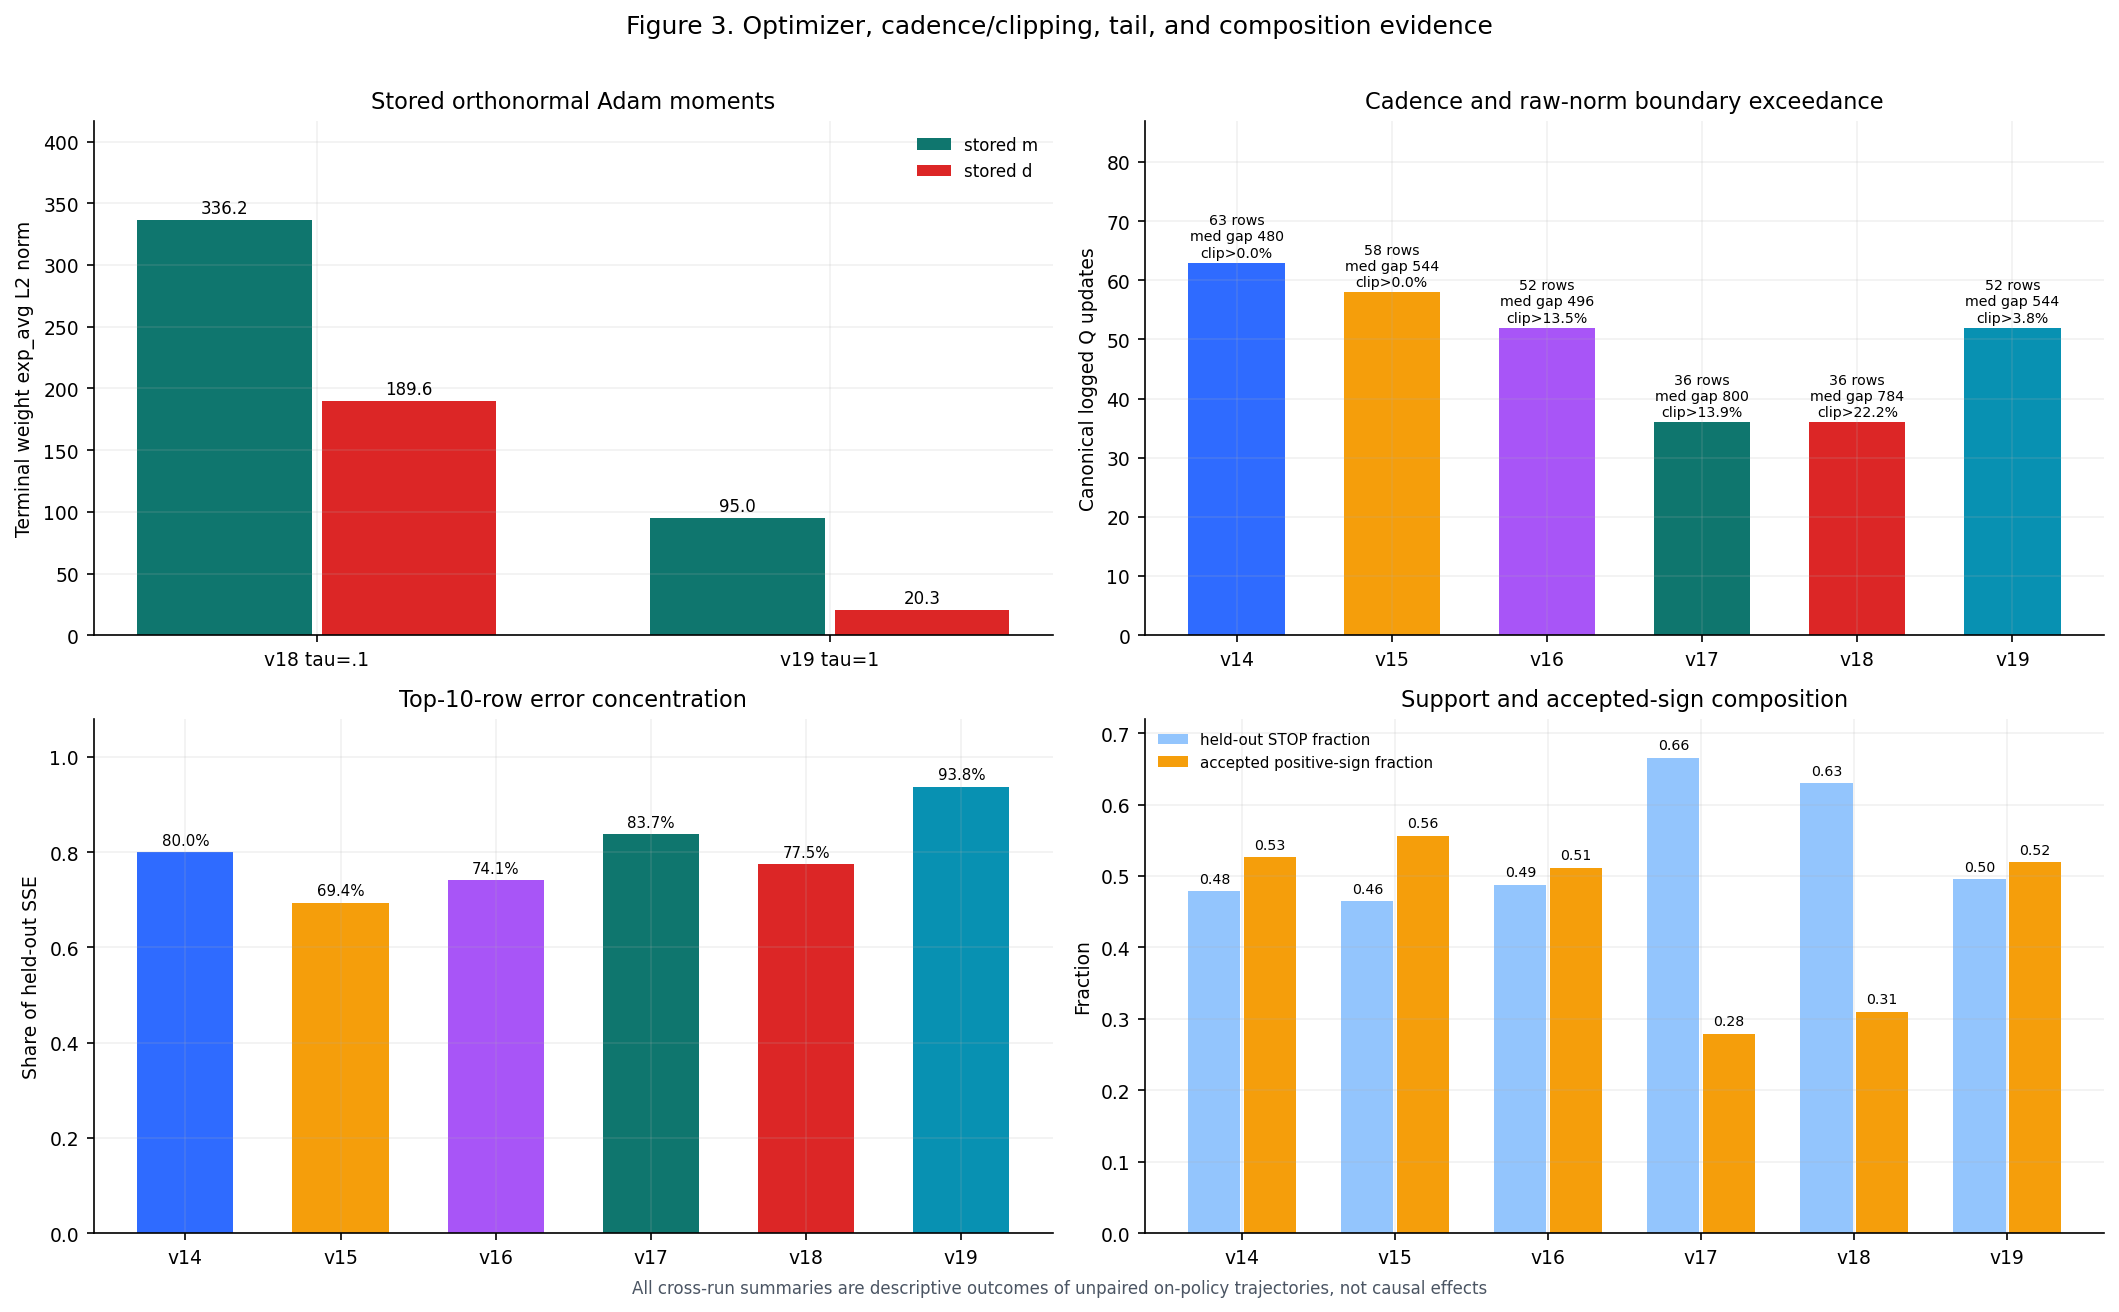

In [7]:
concentration_rows, tail_rows, composition_rows, regime_rows, clip_rows, cadence_rows = [], [], [], [], [], []
VOC_Q_CLIP_BOUNDARY = 0.5 * 201 * 16
assert VOC_Q_CLIP_BOUNDARY == 1608.0
for version, frame in canonical.items():
    full_frame = frames[version]
    clip_rows.append({
        'version': version, 'nominal_clip_boundary': VOC_Q_CLIP_BOUNDARY,
        'all_csv_rows': len(full_frame),
        'all_csv_boundary_exceedances': int((full_frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
        'canonical_rows': len(frame),
        'canonical_boundary_exceedances': int((frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
    })
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    row_sse = pd.Series(holdout_n * np.square(row_rmse)).sort_values(ascending=False)
    for top_k in (1, 5, 10):
        concentration_rows.append({
            'version': version, 'top_rows': top_k, 'sse': float(row_sse.head(top_k).sum()),
            'share_of_total_sse': float(row_sse.head(top_k).sum() / row_sse.sum()),
        })
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    all_n = train_n + holdout_n.astype(np.int64)
    train_sse_rows = (
        all_n * np.square(frame['actor/voc_td_rmse'].to_numpy(dtype=np.float64))
        - holdout_n * np.square(frame['actor/voc_holdout_td_rmse'].to_numpy(dtype=np.float64))
    )
    train_half_mse = float(train_sse_rows.sum() / (2.0 * train_n.sum()))
    logged_loss = float(np.dot(train_n, frame['actor/voc_q_loss'].to_numpy(dtype=np.float64)) / train_n.sum())
    tail_rows.append({
        'version': version, 'logged_loss_definition': VERSIONS[version]['loss'],
        'logged_loss': logged_loss, 'reconstructed_train_half_mse': train_half_mse,
        'mse_minus_2huber': 2.0 * (train_half_mse - logged_loss) if version in ('v14','v17','v18','v19') else np.nan,
        'tail_energy_fraction': (train_half_mse - logged_loss) / train_half_mse if version in ('v14','v17','v18','v19') else np.nan,
    })
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    accept_positive = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_positive_count'], 'accept positive').sum())
    accept_negative = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_negative_count'], 'accept negative').sum())
    composition = {
        'version': version, 'train_continue': train_continue, 'train_stop': train_stop,
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue': holdout_continue, 'holdout_stop': holdout_stop,
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'accept_positive': accept_positive, 'accept_negative': accept_negative,
        'accept_positive_fraction': accept_positive / (accept_positive + accept_negative),
    }
    for label, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        composition[f'{label}_support_share'] = require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum() / holdout_n.sum()
        if label == 'W3':
            composition['W3_accept_positive'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_positive_count'], 'W3 accept positive').sum())
            composition['W3_accept_negative'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_negative_count'], 'W3 accept negative').sum())
    composition_rows.append(composition)
    step_gaps = np.diff(frame.real_step.to_numpy(dtype=np.int64))
    cadence_rows.append({
        'version': version, 'all_csv_rows': len(full_frame), 'canonical_rows': len(frame),
        'median_real_step_gap': float(np.median(step_gaps)), 'mean_real_step_gap': float(np.mean(step_gaps)),
        'train_support': int(train_n.sum()), 'train_support_per_update': float(train_n.sum() / len(frame)),
    })
    work = frame.copy()
    work['train_count'] = train_n
    work['train_half_mse'] = train_sse_rows / (2.0 * train_n)
    assert (work['actor/voc_optimizer_stepped'] == 1).all()
    assert (work['actor/voc_gate_optimizer_stepped'] == 0).all()
    assert (work['actor/voc_gate_projection_post_error_norm'] == 0).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_ema_gate_update_count']).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_gate_update_count']).all()
    assert np.all(np.diff(work['actor/voc_update_count']) == 1)
    for label, lower, upper in (*WINDOWS, ('Full', LOWER_STEP, UPPER_STEP)):
        window = work.loc[(work.real_step > lower) & (work.real_step <= upper)]
        window_support = int(window.train_count.sum())
        updates = int(window['actor/voc_optimizer_stepped'].sum())
        regime_rows.append({
            'version': version, 'window': label, 'updates': updates, 'train_support': window_support,
            'train_support_per_update': window_support / updates,
            'logged_q_loss': float(np.dot(window.train_count, window['actor/voc_q_loss']) / window_support),
            'reconstructed_train_half_mse': float(np.dot(window.train_count, window.train_half_mse) / window_support),
            'q_raw_norm_mean': float(window['actor/voc_total_norm'].mean()),
            'q_raw_norm_median': float(window['actor/voc_total_norm'].median()),
            'q_raw_norm_p95': float(window['actor/voc_total_norm'].quantile(0.95)),
            'q_raw_norm_max': float(window['actor/voc_total_norm'].max()),
        })

concentration = pd.DataFrame(concentration_rows)
tail_observability = pd.DataFrame(tail_rows)
composition = pd.DataFrame(composition_rows)
regimes = pd.DataFrame(regime_rows)
clip_summary = pd.DataFrame(clip_rows)
cadence = pd.DataFrame(cadence_rows)
full_regimes = regimes.loc[regimes.window == 'Full'].reset_index(drop=True)
expected_top10={'v14':0.7999049615724924,'v15':0.6939299981526046,'v16':0.7408296126900793,'v17':0.8373002087229751,'v18':0.7751888288462382,'v19':0.937513296891815}
for version, expected in expected_top10.items():
    actual = concentration.query('version == @version and top_rows == 10').share_of_total_sse.iloc[0]
    assert np.isclose(actual,expected,rtol=0.0,atol=1e-14)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_median'], 428.2610778808594, rtol=0.0, atol=1e-12)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_p95'], 1842.8370300292963, rtol=0.0, atol=1e-10)
assert clip_summary.set_index('version')[['all_csv_boundary_exceedances', 'canonical_boundary_exceedances']].to_dict('index') == {
    'v14': {'all_csv_boundary_exceedances': 0, 'canonical_boundary_exceedances': 0},
    'v15': {'all_csv_boundary_exceedances': 1, 'canonical_boundary_exceedances': 0},
    'v16': {'all_csv_boundary_exceedances': 35, 'canonical_boundary_exceedances': 7},
    'v17':{'all_csv_boundary_exceedances':14,'canonical_boundary_exceedances':5},
    'v18':{'all_csv_boundary_exceedances':13,'canonical_boundary_exceedances':8},
    'v19':{'all_csv_boundary_exceedances':15,'canonical_boundary_exceedances':2},
}
assert composition.set_index('version').loc['v16', ['W3_accept_positive', 'W3_accept_negative']].astype(int).tolist() == [1, 11722]
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(concentration)
    display(tail_observability)
    display(composition)
    display(clip_summary)
    display(cadence)
    display(regimes)

fig,axes=plt.subplots(2,2,figsize=(14.2,8.4));versions=list(VERSIONS);x=np.arange(len(versions),dtype=float)
# Optimizer-state semantics: only v18/v19 rows are directly comparable as stored m/d moments.
state_index=checkpoint_state.set_index('version').loc[['v18','v19']];cx=np.arange(2);vals=state_index[['moment_row0_or_m_norm','moment_row1_or_d_norm']].to_numpy()
axes[0,0].bar(cx-.18,vals[:,0],width=.34,color='#0F766E',label='stored m');axes[0,0].bar(cx+.18,vals[:,1],width=.34,color='#DC2626',label='stored d')
for col,off in [(0,-.18),(1,.18)]:
    for xpos,value in zip(cx,vals[:,col]): axes[0,0].text(xpos+off,value+6,f'{value:.1f}',ha='center',fontsize=8)
axes[0,0].set_xticks(cx,['v18 tau=.1','v19 tau=1']);axes[0,0].set_ylim(0,vals.max()*1.24);axes[0,0].set_ylabel('Terminal weight exp_avg L2 norm');axes[0,0].set_title('Stored orthonormal Adam moments');axes[0,0].legend(frameon=False,fontsize=8)
# Cadence and clipping-boundary regime.
cd=cadence.set_index('version').loc[versions];ci=clip_summary.set_index('version').loc[versions];clip_fraction=ci.canonical_boundary_exceedances/ci.canonical_rows
bars=axes[0,1].bar(x,cd.canonical_rows,color=[COLORS[v] for v in versions],width=.62,label='canonical rows')
for bar,rows,gap,clip in zip(bars,cd.canonical_rows,cd.median_real_step_gap,clip_fraction): axes[0,1].text(bar.get_x()+bar.get_width()/2,rows+1,f'{int(rows)} rows\nmed gap {int(gap)}\nclip>{clip:.1%}',ha='center',fontsize=6.8)
axes[0,1].set_xticks(x,versions);axes[0,1].set_ylim(0,cd.canonical_rows.max()*1.38);axes[0,1].set_ylabel('Canonical logged Q updates');axes[0,1].set_title('Cadence and raw-norm boundary exceedance')
# Tail concentration.
top10=concentration.query('top_rows == 10').set_index('version').loc[versions,'share_of_total_sse']
axes[1,0].bar(x,top10,color=[COLORS[v] for v in versions],width=.62)
for xpos,value in zip(x,top10): axes[1,0].text(xpos,value+.015,f'{value:.1%}',ha='center',fontsize=7.2)
axes[1,0].set_xticks(x,versions);axes[1,0].set_ylim(0,1.08);axes[1,0].set_ylabel('Share of held-out SSE');axes[1,0].set_title('Top-10-row error concentration')
# Composition.
comp=composition.set_index('version').loc[versions];stop=comp.holdout_stop_fraction;positive=comp.accept_positive_fraction
axes[1,1].bar(x-.18,stop,width=.34,color='#93C5FD',label='held-out STOP fraction');axes[1,1].bar(x+.18,positive,width=.34,color='#F59E0B',label='accepted positive-sign fraction')
for series,off in [(stop,-.18),(positive,.18)]:
    for xpos,value in zip(x,series): axes[1,1].text(xpos+off,value+.012,f'{value:.2f}',ha='center',fontsize=6.8)
axes[1,1].set_xticks(x,versions);axes[1,1].set_ylim(0,.72);axes[1,1].set_ylabel('Fraction');axes[1,1].set_title('Support and accepted-sign composition');axes[1,1].legend(frameon=False,fontsize=7.2,loc='upper left')
fig.suptitle('Figure 3. Optimizer, cadence/clipping, tail, and composition evidence',fontsize=12,y=1.01)
fig.text(.5,-.005,'All cross-run summaries are descriptive outcomes of unpaired on-policy trajectories, not causal effects',ha='center',color='#4B5563',fontsize=8)
fig.tight_layout();plt.show();rendered_figure_count+=1
assert rendered_figure_count == 3


## Evidence, causal limits, and V20 consensus ranking

### Frozen evidence

1. **The hard outcomes are arithmetically determined.** V14/v15 fail only held-out EMA RMSE; v16 fails RMSE plus trailing-denominator validity; v17 passes RMSE but fails denominator validity; v18 fails both; v19 fails only RMSE. V19 has RMSE `0.5251721239` (N=7,637; SSE `2106.32858701171`) and 48/48 defined trailing-five endpoints. Numeric acceptance is conjunctive.
2. **Tau=1 clears the predecessor's EMA-only denominator lag but does not clear calibration.** Every logged v19 online/EMA sufficient statistic is equal, and no trailing endpoint is undefined. Yet v19 online=EMA RMSE is above 0.5. W1/W2/W3 RMSE is `0.949422/0.044122/0.508140`; their SSE shares are 81.7812%/0.3948%/17.8240%. This is observed evidence, not the isolated effect of tau, because v18 and v19 are different on-policy trajectories.
3. **The v19 error is temporally and row-wise concentrated, without a simple aggregate-bias explanation.** Rows 71824 and 73600 alone contribute 55.9986% of full SSE but have opposite held-out bias signs (`+0.638174` and `-1.677602`); pooled bias is only `-0.021300`. V19 has a strict-population zero-positive run at 95680–97760 and zero-negative rows at 87024/87168, but minimum trailing-five positive/negative support is 60/7, so every endpoint remains defined. Denominator validity is not an RMSE proxy.
4. **Norm, clipping-boundary, cadence, tail, and composition differ.** V19 has 52 canonical updates, median real-step gap 544, 2/52 canonical raw norms above 1,608, and top-ten rows contribute 93.7513% of held-out SSE. These outcomes cannot be used to remove rows, reweight the frozen population, or identify a treatment effect.
5. **Checkpoint state confirms intended mechanics, not a cause.** V18/v19 step-480 raw online Q parameters and Q-Adam state are bitwise equal; EMA and projected gate differ at the inherited tau arithmetic boundary. V19 terminal raw EMA weight/bias are `torch.equal` to raw online and the gate exactly projects the raw difference. Terminal stored m/d moment magnitudes reflect different trajectories and are not treatment-comparable.
6. **Mechanics cannot rescue numeric failure.** Every run has hash-bound finish, checkpoints, provenance, source/data manifests, driver log, and exact child exit. V19 W&B local run bytes and final complete/exit-0 HTTP-200 filestream evidence are bound. V19 remains permanently failed; no retry, resume, primary, or fixed evaluation is authorized.

### What is not identified

There is one seed and one separately generated on-policy run per version, no paired state sequence, randomized factorial isolation, or event-level counterfactual residuals. V19 changes EMA tau relative to v18 and consequently changes rollout policy, state visitation, targets, gradients, cadence, support, and learned parameters. The notebook does **not** estimate a treatment effect, identify a unique root cause, or predict a future pass.

### Formal A/B-consensus ranked V20 hypotheses

1. **Behavior-preserving schema-13 telemetry only, before any new behavior.** Keep objective, optimizer, learning rates, clipping, cadence, EMA/projection, sampling, RNG, batches, counters, schedulers, state, and all inherited decisions unchanged. Keep the legacy 922-column `logs.csv` schema and legacy W&B metric payload unchanged; hash-bind separate telemetry sidecars and their manifest, and do not grow the 229/209 config key counts. At every actor-log update, record exact `q_source ∈ {online, EMA}` × split `(train/holdout)` × selected action `(CONTINUE/STOP)` × depth `(0,1,2–3,4–7,8–15,16+)` × TD sign × `|TD|` bands `[0,.5),[.5,1),[1,2),[2,4),[4,∞)`, deriving `selectedQ` and TD independently from each exact Q source, with count, `Σtarget`, `Σtarget²`, `ΣselectedQ`, `ΣselectedQ²`, `Σtarget·selectedQ`, `Σtd`, `Σ|td|`, `Σtd²`, and `max|td|`. For every Q attempt, record real step/update/status, raw C/S preclip and postclip gradient L2, clip scale, transformed m/d gradient L2, m/v statistics, bias-corrected normalized update L2, and inverse-mapped raw delta L2. Record only primitive existing replay facts: `real_step` before/delta/after, actor/batch/policy IDs, train/holdout support, Q attempt/status, counters, scheduler before/after, and publication/ack. Schema 13 defines no quantum, credit, backlog, reuse, or restore semantics. Observe detached/pre-backward values, post-unscale/clip values, and adapter-candidate precommit values; append the sidecars only after the inherited Q→actor→EMA→projection→counters→scheduler→publication/ack path has completed. Behavior-preserving means fixed-input tensor/state/RNG/counter and legacy-log/W&B-payload noninterference, not identical asynchronous wall-clock timing. Offline telemetry acceptance fails closed on any count-reconstruction, noninterference, or append/drop-ordering violation. **Falsifier:** any fixed-input tensor/state/RNG/counter/old-column drift, legacy `logs.csv` or W&B metric-payload drift, missing sufficient-statistic reconstruction, telemetry-dependent control, or evidence-order violation.
2. **Deterministic real-step VoC-Q cadence mechanism class, only after telemetry.** A future preregistration would have to freeze the exact quantum and boundary-credit rule, FIFO backlog, per-batch consumption cap, no batch reuse, no dropped credit, support assignment, Q-skip semantics, scheduler/counter ordering, and checkpoint/restore behavior. The evidence identifies no honest numeric quantum or backlog value: hardcoding 512, 800, or another post-hoc value is unsupported. This class is not implementation-ready. **Falsifier:** duplicated/reused data, dropped/unrestored credit, more than the frozen updates per batch, non-Q state drift, or any cadence mismatch.
3. **Q-only coordinate step/LR/clip sensitivity class, only after telemetry.** If telemetry identifies a residual-linked update mechanism, a later one-lever preregistration may vary a dedicated Q-only coordinate step size, learning rate, or clipping rule while leaving the actor and all other semantics fixed. Direction, parameter, and value are deliberately unspecified; `0.00015`, half-LR, global actor LR, or a shared clip change are not evidence-licensed choices. V19 has only 2/52 raw-Q boundary exceedances, and one of its two largest-SSE rows has raw norm only 199.756, so current evidence does not support a direction. **Falsifier:** actor-state change, moment/clip/order drift outside the frozen Q-only lever, or any unregistered second semantic change.

All three entries are information-gain priorities. The six runs are unpaired single-seed on-policy trajectories; no entry has a causal estimate or pass forecast. If an immediate behavior-changing V20 is mandated, the evidence is insufficient to select an honest value.

### Acceptance boundary

Denominator relaxation, pseudocounts, endpoint removal, threshold/window/support changes, rescue seeds, post-hoc row selection, or multi-lever changes are not candidates. Any later ranking orders falsifiable questions only; it is not a preregistration, implementation instruction, launch authorization, or pass promise.


In [8]:
audit={
 'production_python':{'version':platform.python_version(),'executable':str(Path(sys.executable).resolve())},
 'protocol_population':'70000 < real_step <= 100000',
 'actor_csv_sha256':{v:s['actor_sha256'] for v,s in VERSIONS.items()},
 'model_csv_sha256':{v:s['model_sha256'] for v,s in VERSIONS.items()},
 'actor_checkpoint_sha256':{v:s['actor_checkpoint_sha256'] for v,s in VERSIONS.items()},
 'model_checkpoint_sha256':{v:s['model_checkpoint_sha256'] for v,s in VERSIONS.items()},
 'config_sha256':{v:s['config_sha256'] for v,s in VERSIONS.items()},
 'finish_sha256':{v:s['finish_sha256'] for v,s in VERSIONS.items()},
 'launch_sha256':{v:s['launch_sha256'] for v,s in VERSIONS.items()},
 'driver_log_sha256':{v:s['driver_log_sha256'] for v,s in VERSIONS.items()},
 'driver_exit_sha256':{v:s['driver_exit_sha256'] for v,s in VERSIONS.items()},
 'source_manifest_sha256':{v:s['source_manifest_sha256'] for v,s in VERSIONS.items()},
 'data_manifest_sha256':{v:s['data_manifest_sha256'] for v,s in VERSIONS.items()},
 'prereg_sha256':{v:s['protocol_sha256'] for v,s in VERSIONS.items()},
 'external_rca_sha256':{label:expected for label,(_,expected) in EXTERNAL_RCA.items()},
 'v19_wandb_local_sha256':V19_WANDB_EVIDENCE,
 'v19_run_tree_sha256':V19_RUN_TREE_SHA256,
 'v19_public_evidence_sha256':V19_PUBLIC_EVIDENCE_SHA256,
 'canonical_population':{v:s['canonical'] for v,s in VERSIONS.items()},
 'heldout_ema_rmse':{v:authoritative[v]['heldout_ema_rmse'] for v in VERSIONS},
 'heldout_ema_sse':{row.version:row.ema_sse for row in full_sse.itertuples(index=False)},
 'csv_observable_hard_gate_failures':failure_sets,
 'undefined_trailing_five_endpoints':{v:trailing_results[v].loc[trailing_results[v].student_gap.isna(),'real_step'].astype(int).tolist() for v in VERSIONS},
 'v18_v19_sign_chronology':chronology,
 'ema_extinction_composition':extinction_composition.set_index('version').to_dict('index'),
 'raw_q_boundary_exceedances':{row.version:{'boundary':row.nominal_clip_boundary,'all_csv':f'{row.all_csv_boundary_exceedances}/{row.all_csv_rows}','canonical':f'{row.canonical_boundary_exceedances}/{row.canonical_rows}'} for row in clip_summary.itertuples(index=False)},
 'step_checkpoint_sha256':{label:h for label,(_,h) in STEP_CHECKPOINTS.items()},
 'checkpoint_state':checkpoint_state.set_index('version').to_dict('index'),
 'coordinate_diagnostic':coordinate_diagnostic,
 'A_B_consensus_ranked_hypotheses':['schema13_behavior_preserving_telemetry_only','deterministic_real_step_voc_q_cadence_mechanism_values_unspecified_pending_telemetry','q_only_coordinate_step_lr_clip_sensitivity_direction_value_unspecified_pending_telemetry'],
 'embedded_figures':rendered_figure_count,'causal_effect_estimated':False,'pass_prediction_made':False,'implementation_launch_or_evaluation_performed':False,
}
assert audit['production_python']['version']=='3.10.21'
assert audit['csv_observable_hard_gate_failures']=={'v14':['heldout_ema_rmse'],'v15':['heldout_ema_rmse'],'v16':['trailing_denominators_valid','heldout_ema_rmse'],'v17':['trailing_denominators_valid'],'v18':['trailing_denominators_valid','heldout_ema_rmse'],'v19':['heldout_ema_rmse']}
assert audit['undefined_trailing_five_endpoints']['v19']==[]
assert audit['v18_v19_sign_chronology']['v19']['online_trailing_invalid_endpoints']==[]
assert np.isclose(audit['heldout_ema_sse']['v19'],2106.32858701171,rtol=0,atol=1e-10)
assert np.isclose(split_moments.query("version=='v19' and q_source=='Online' and split=='holdout'").rmse.iloc[0],0.5251721239021903,rtol=0,atol=1e-14)
assert audit['coordinate_diagnostic']['v19_terminal_raw_online_equals_raw_ema_torch_equal']
assert audit['A_B_consensus_ranked_hypotheses']==['schema13_behavior_preserving_telemetry_only','deterministic_real_step_voc_q_cadence_mechanism_values_unspecified_pending_telemetry','q_only_coordinate_step_lr_clip_sensitivity_direction_value_unspecified_pending_telemetry']
print(json.dumps(audit,indent=2,sort_keys=True))


{
  "A_B_consensus_ranked_hypotheses": [
    "schema13_behavior_preserving_telemetry_only",
    "deterministic_real_step_voc_q_cadence_mechanism_values_unspecified_pending_telemetry",
    "q_only_coordinate_step_lr_clip_sensitivity_direction_value_unspecified_pending_telemetry"
  ],
  "actor_checkpoint_sha256": {
    "v14": "a86094cc3131bbe55bd5ac5995203cf8f3830ab36fbaf60e630306b0fe1d107c",
    "v15": "ee41fa3f0916f5b726b6cd448e12989abbe01554a69c6f4eb5ab8ed434cd2c7c",
    "v16": "c05a2237b495ff36fe633446e8236a93d2e07da9038f01781ac3b5026e947b7d",
    "v17": "1054956ebbb8a1b75cb1d2eed54611c90d785c83ee3fc9a7d6d40e2c85430eb0",
    "v18": "b07a7318145e668d86807b413d418e955556fe7f178bf4c2116b0cb972b1f2fc",
    "v19": "e0451e4d396e1b8ec464d568a110b8c35d5838ee1f2578aa9604571a14ad88d3"
  },
  "actor_csv_sha256": {
    "v14": "6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8",
    "v15": "359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341",
    "v16": "45da4532357f5

## Takeaways

- Exact frozen bytes and the strict population reproduce v14–v19 held-out EMA RMSE at `0.5247954789/0.5637126652/0.6433996229/0.4739621233/0.6213871747/0.5251721239`.
- V19 clears all 48 trailing denominators but fails RMSE, so exactly 14/15 CSV-observable gates pass. V19 online and EMA statistics are equal; therefore tau=1 removes the observed EMA/online lag without guaranteeing calibration or acceptance.
- V19 W1 RMSE is `0.949422`, while W2 is `0.044122` and W3 is `0.508140`; top-ten rows account for 93.7513% of SSE. This concentration is diagnostic evidence, not authority to trim or reweight rows.
- Formal A/B consensus ranks behavior-preserving schema-13 telemetry first. Cadence is second and Q-only coordinate step/LR/clip sensitivity third, but both numeric contracts remain deliberately unspecified until telemetry supplies evidence; neither is implementation-ready.
- Nothing here authorizes implementation, launch, evaluation, retry/rescue, or any relaxation of denominator, RMSE, support, window, or threshold rules.
